In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Imports and Style Setup
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
})

# Colour palette
BLUE   = '#2E75B6'
ORANGE = '#ED7D31'
GREEN  = '#70AD47'
RED    = '#C00000'
GOLD   = '#FFC000'
TEAL   = '#00B0A0'
GRAY   = '#7F7F7F'
LIGHT_GREEN = '#E2EFDA'
LIGHT_RED   = '#FCE4D6'

CAT_PALETTE = [
    '#2E75B6','#ED7D31','#70AD47','#C00000','#FFC000','#00B0A0',
    '#7030A0','#9E480E','#43682B','#264478','#622366','#7F7F7F',
    '#4472C4','#FF6600','#006600','#003366','#660033',
]

CAT_MAP = {
    'WI':'Writing Instruments', 'PP':'Paper Products',
    'FF':'Files & Folders',     'OD':'Office Desk Supplies',
    'AT':'Adhesives & Tapes',   'CE':'Correction & Erasing',
    'MG':'Measurement & Geometry', 'AC':'Art & Craft Supplies',
    'SS':'School Supplies',     'OF':'Office Forms & Registers',
    'PC':'Printing & Computer', 'FB':'Fasteners & Binding',
    'EM':'Envelopes & Mailing', 'MU':'Miscellaneous / Utility',
    'TG':'Toys & Games',        'EL':'Electronics & Accessories',
    'SV':'Services',            'XX':'Unclassified',
}

print("Setup complete.")


# ─────────────────────────────────────────────────────────────────────────────
# Upload and Load Data
# ─────────────────────────────────────────────────────────────────────────────
print("Upload Inventory_Data_Updated.csv and Sales_Data_Updated.csv")
uploaded = files.upload()

inv = pd.read_csv('Inventory_Data_v3.csv')
sal = pd.read_csv('Sales_Data_v3.csv')

# ── Inventory cleaning ───────────────────────────────────────────────────────
inv['Rate']       = pd.to_numeric(inv['Rate'],        errors='coerce')
inv['Cost Price'] = pd.to_numeric(inv['Cost Price'],  errors='coerce')
inv['Qty']        = pd.to_numeric(inv['Qty'],         errors='coerce')
inv['StockValue'] = inv['Rate'] * inv['Qty']
inv['Margin_pct'] = ((inv['Rate'] - inv['Cost Price']) / inv['Rate'] * 100).round(1)
inv['CatCode']    = inv['SKU Code'].str[:2]
inv['CatLabel']   = inv['CatCode'].map(CAT_MAP).fillna(inv['Category'])
inv_known = inv[inv['Category'] != 'Services'].dropna(subset=['Rate','Cost Price']).copy()
inv_known = inv_known[inv_known['Rate'] > 0].copy()

# ── Sales cleaning ────────────────────────────────────────────────────────────
sal['Date']     = pd.to_datetime(sal['Date'], format='%d-%m-%Y', errors='coerce')
sal['Revenue']  = pd.to_numeric(sal['Cost (₹)'],  errors='coerce')
sal['Rate_s']   = pd.to_numeric(sal['Rate (₹)'],  errors='coerce')
sal['Qty_s']    = pd.to_numeric(sal['Qty'],        errors='coerce')
sal['Hour']     = sal['Time'].str.split(':').str[0].astype(float)
sal['DayLabel'] = sal['Date'].dt.strftime('%d %b')
date_order = sal.drop_duplicates('DayLabel').sort_values('Date')['DayLabel'].tolist()

TOD_ORDER = ['Morning (9–12)', 'Afternoon (12–15)', 'Evening (15–18)', 'Night (18–21)']
def time_bucket(h):
    if pd.isna(h):  return None
    if h < 12:      return 'Morning (9–12)'
    if h < 15:      return 'Afternoon (12–15)'
    if h < 18:      return 'Evening (15–18)'
    return              'Night (18–21)'
sal['TimeOfDay'] = sal['Hour'].apply(time_bucket)

sal['CatCode']   = sal['SKU'].str[:2]
sal['Category']  = sal['CatCode'].map(CAT_MAP).fillna('Other')

print(f"Loaded: {len(sal)} sales rows | {len(inv_known)} priced inventory SKUs")
print(f"   Sales: {sal['Date'].min().date()} → {sal['Date'].max().date()}")
print(f"   Inventory categories: {inv_known['Category'].nunique()}")


Setup complete.
Upload Inventory_Data_Updated.csv and Sales_Data_Updated.csv


Saving Sales_Data_v3.csv to Sales_Data_v3.csv
Saving Inventory_Data_v3.csv to Inventory_Data_v3.csv
Loaded: 458 sales rows | 657 priced inventory SKUs
   Sales: 2026-02-10 → 2026-03-10
   Inventory categories: 16


# FIGURE 3.1
Scatter Plot: Selling Rate vs Cost Price per SKU (all 664 SKUs)
PS 1.1 — Profitability Visibility Gap

WHY THIS CHART:
This scatter shows ALL 664 priced SKUs at once, making the full distribution
of margins visible. Dots near the break-even line expose thin-margin products
hiding in the middle of the catalogue. The 20% margin reference line shows
exactly which SKUs fall below the owner's assumption.

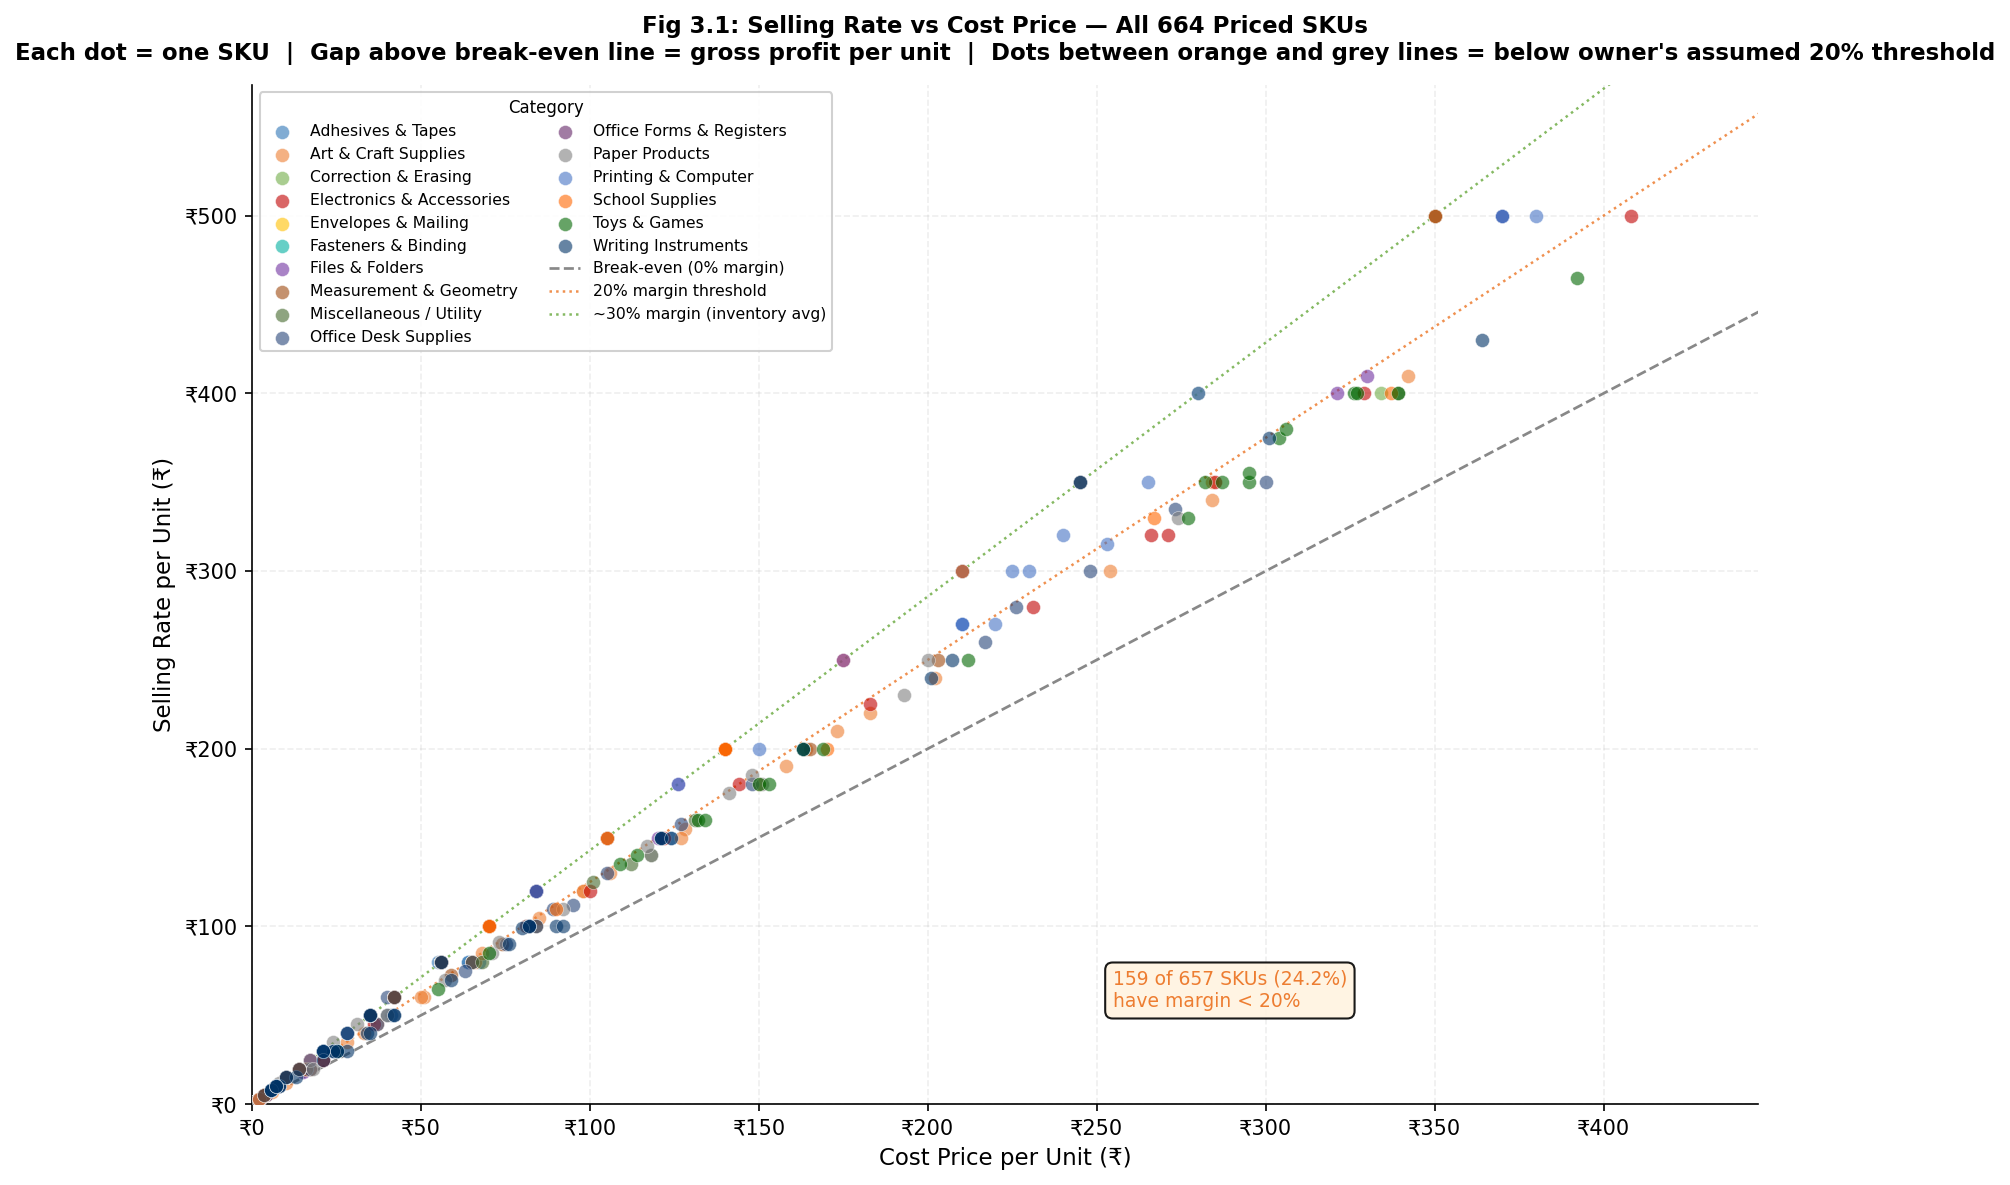

Saved: fig3_1_scatter_rate_cp.png

SKUs below 20% margin: 159 (24.2% of catalogue)
SKUs above 30% margin: 455 (69.3%)


In [ ]:
# formerly 5.4
cats_sorted = sorted(inv_known['CatLabel'].dropna().unique())
cat_color_map = {c: CAT_PALETTE[i % len(CAT_PALETTE)] for i, c in enumerate(cats_sorted)}

# Clip to 97th percentile for readability (outliers compress the main cluster)
clip_rate = inv_known['Rate'].quantile(0.97)
clip_cp   = inv_known['Cost Price'].quantile(0.97)
plot_data = inv_known[(inv_known['Rate'] <= clip_rate) &
                      (inv_known['Cost Price'] <= clip_cp)].copy()

fig, ax = plt.subplots(figsize=(11, 8))

for cat in cats_sorted:
    grp = plot_data[plot_data['CatLabel'] == cat]
    ax.scatter(grp['Cost Price'], grp['Rate'],
               color=cat_color_map[cat], alpha=0.6, s=45,
               edgecolors='white', linewidth=0.3, label=cat, zorder=3)

max_val = max(plot_data['Rate'].max(), plot_data['Cost Price'].max()) * 1.05
x_ref = np.linspace(0, max_val, 300)

# Break-even line (0% margin)
ax.plot([0, max_val], [0, max_val], color='#888', linewidth=1.3,
        linestyle='--', label='Break-even (0% margin)', zorder=2)
# 20% margin line (owner's lower assumed threshold)
ax.plot(x_ref, x_ref / 0.80, color=ORANGE, linewidth=1.2,
        linestyle=':', alpha=0.85, label='20% margin threshold', zorder=2)
# 30% margin line (inventory average)
ax.plot(x_ref, x_ref / 0.70, color=GREEN, linewidth=1.2,
        linestyle=':', alpha=0.85, label='~30% margin (inventory avg)', zorder=2)

ax.set_xlabel('Cost Price per Unit (₹)', fontsize=11)
ax.set_ylabel('Selling Rate per Unit (₹)', fontsize=11)
ax.set_xlim(0, clip_cp * 1.05)
ax.set_ylim(0, clip_rate * 1.05)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
ax.grid(True, alpha=0.2, linestyle='--')

# Count SKUs below 20% margin for annotation
below_20 = (inv_known['Margin_pct'] < 20).sum()
total    = len(inv_known)
ax.text(clip_cp*0.60, clip_rate*0.10,
        f'{below_20} of {total} SKUs ({below_20/total*100:.1f}%)\nhave margin < 20%',
        fontsize=9, color=ORANGE,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0', alpha=0.9))

ax.legend(fontsize=7.5, ncol=2, loc='upper left',
          framealpha=0.9, title='Category', title_fontsize=8)
ax.set_title(
    'Fig 3.1: Selling Rate vs Cost Price — All 664 Priced SKUs\n'
    'Each dot = one SKU  |  Gap above break-even line = gross profit per unit  |  '
    'Dots between orange and grey lines = below owner\'s assumed 20% threshold',
    fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig3_1_scatter_rate_cp.png')
plt.show()
print("Saved: fig3_1_scatter_rate_cp.png")
print(f"\nSKUs below 20% margin: {below_20} ({below_20/total*100:.1f}% of catalogue)")
print(f"SKUs above 30% margin: {(inv_known['Margin_pct'] >= 30).sum()} ({(inv_known['Margin_pct'] >= 30).sum()/total*100:.1f}%)")


# FIG 3.2
Stacked Bar: Margin Band Distribution by Category
PS 1.1 — Profitability Visibility Gap

WHY THIS CHART:
The scatter (Fig 3.1) shows all SKUs as individual dots. This chart
aggregates to category level, showing what proportion of each category's
SKU catalogue sits below 15%, in the 15–20% band, in the 20–30% band,
and above 30%. A category where most SKUs are below 15% is a systemic
pricing problem, not an isolated one — a finding that requires this
aggregated view to see clearly.

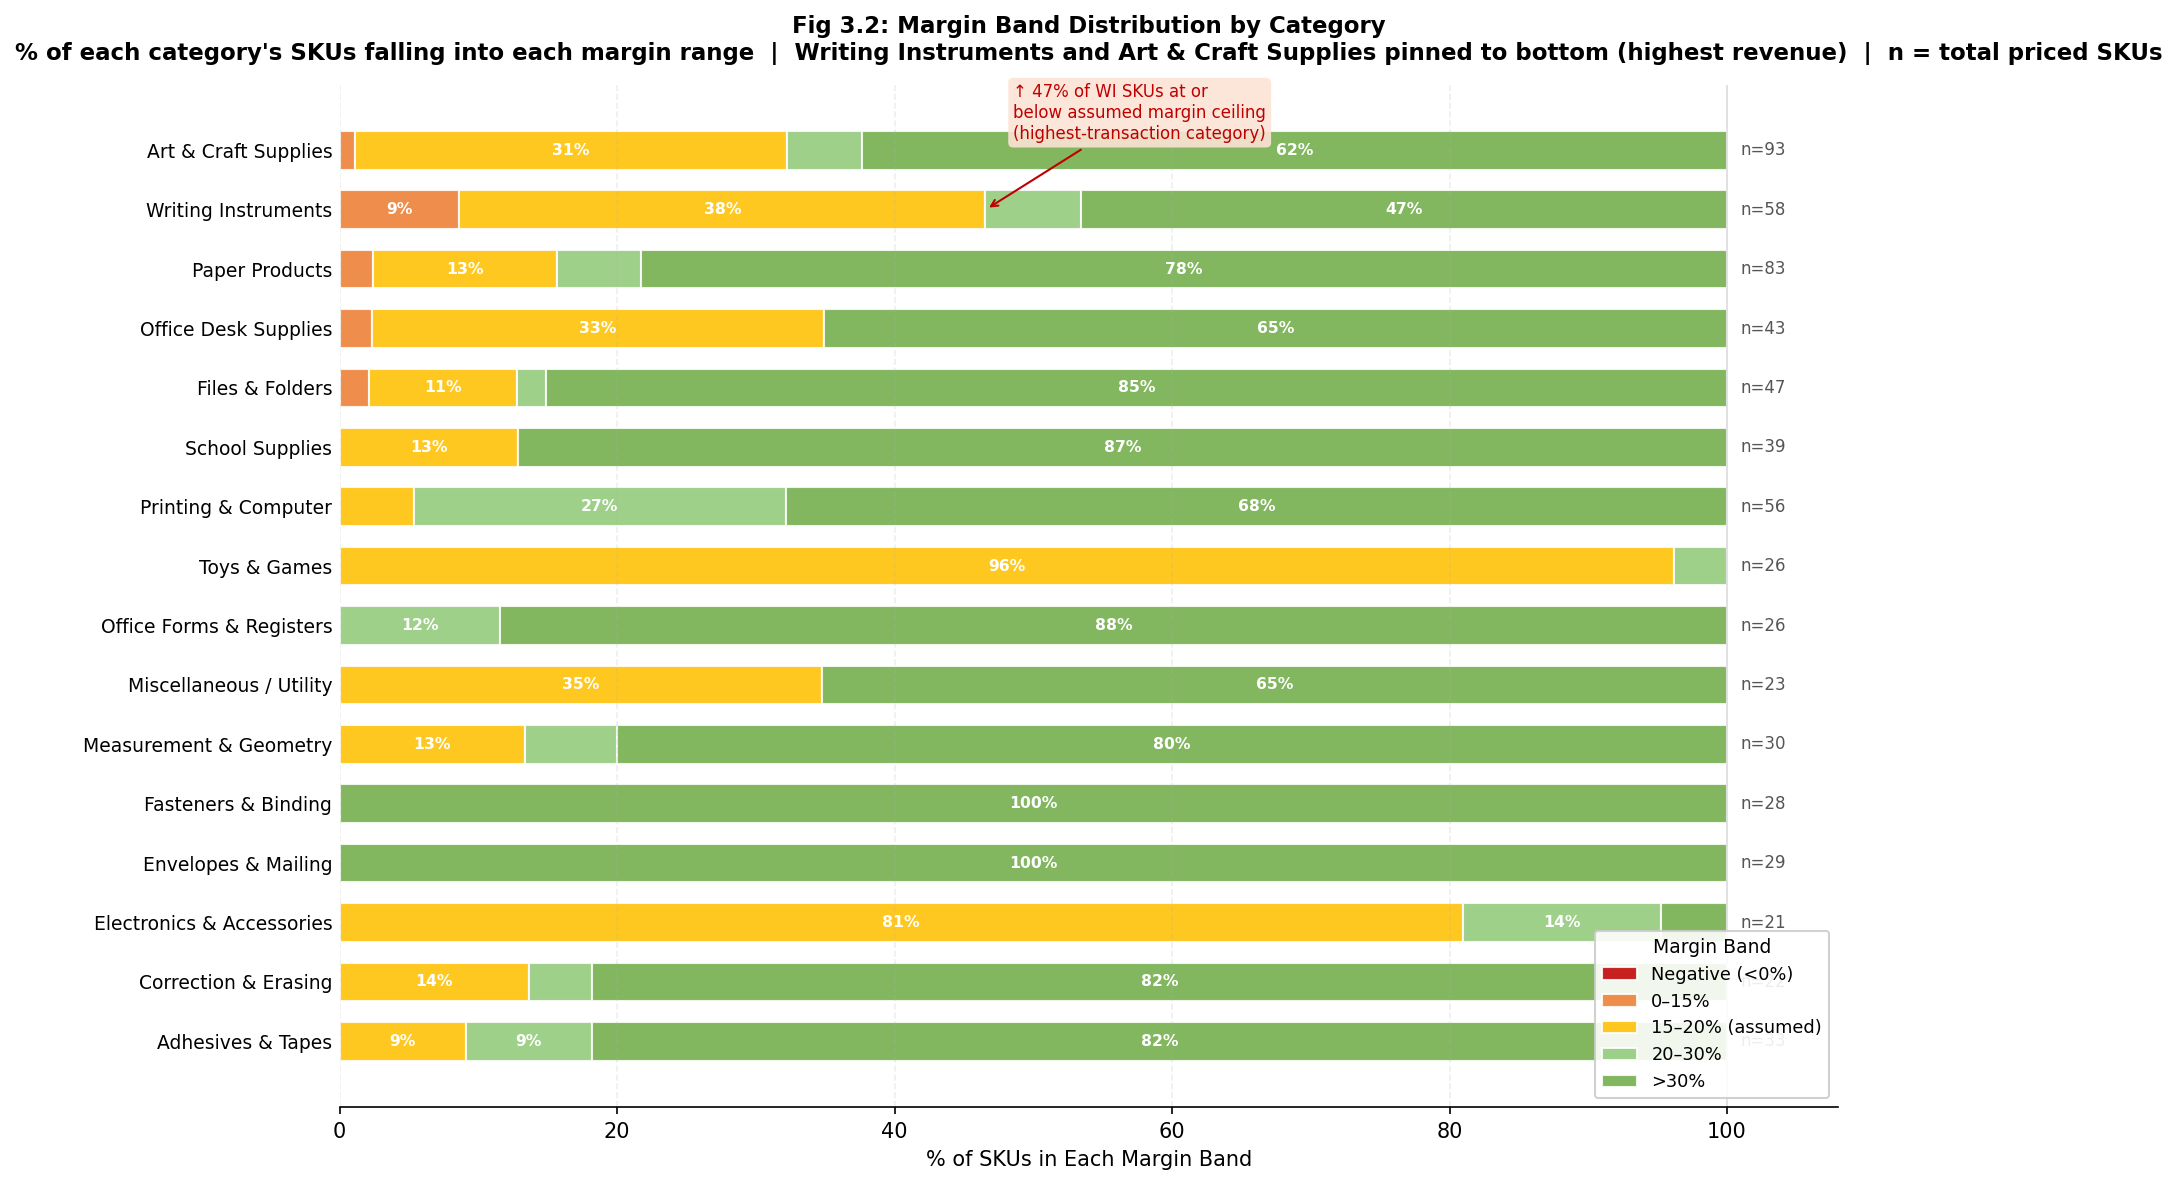

Saved: fig3_2_margin_band_stacked.png

── Margin band breakdown by category ───────────────────────
MarginBand                 Negative (<0%)  0–15%  15–20% (assumed)  20–30%   >30%
CatLabel                                                                         
Adhesives & Tapes                     0.0    0.0               9.1     9.1   81.8
Correction & Erasing                  0.0    0.0              13.6     4.5   81.8
Electronics & Accessories             0.0    0.0              81.0    14.3    4.8
Envelopes & Mailing                   0.0    0.0               0.0     0.0  100.0
Fasteners & Binding                   0.0    0.0               0.0     0.0  100.0
Measurement & Geometry                0.0    0.0              13.3     6.7   80.0
Miscellaneous / Utility               0.0    0.0              34.8     0.0   65.2
Office Forms & Registers              0.0    0.0               0.0    11.5   88.5
Toys & Games                          0.0    0.0              96.2     3.8    0.

In [ ]:
# formerly 5.10

def margin_band(m):
    if m < 0:   return 'Negative (<0%)'
    if m < 15:  return '0–15%'
    if m < 20:  return '15–20% (assumed)'
    if m < 30:  return '20–30%'
    return              '>30%'

inv_known['MarginBand'] = inv_known['Margin_pct'].apply(margin_band)

BAND_ORDER  = ['Negative (<0%)', '0–15%', '15–20% (assumed)', '20–30%', '>30%']
BAND_COLORS = [RED, ORANGE, GOLD, '#90C978', GREEN]

band_counts = (inv_known.groupby(['CatLabel', 'MarginBand'])
               .size().unstack(fill_value=0))
band_counts = band_counts.reindex(columns=BAND_ORDER, fill_value=0)

# Convert to % of each category's SKU count
band_pct = band_counts.div(band_counts.sum(axis=1), axis=0) * 100

# ── SORT FIX ──────────────────────────────────────────────────────────────────
# Sort so that Writing Instruments and Art & Craft Supplies (the two
# highest-revenue categories) end up at the BOTTOM of the chart.
# The reader's eye naturally finishes at the bottom — these are the
# most important rows and should be read last.
#
# Sort order: ascending by combined below-15% proportion so the most
# problematic high-revenue categories land at the bottom.
# Then force WI and AC to the very bottom regardless.
PRIORITY_BOTTOM = ['Writing Instruments', 'Art & Craft Supplies']

band_pct['_below15'] = band_pct['Negative (<0%)'] + band_pct['0–15%']
band_pct['_is_priority'] = band_pct.index.isin(PRIORITY_BOTTOM).astype(int)

# Sort: non-priority rows ascending by below15 (least problematic at top),
# then priority rows at the bottom in fixed order
non_priority = (band_pct[band_pct['_is_priority'] == 0]
                .sort_values('_below15', ascending=True))
priority_rows = band_pct.loc[
    [c for c in PRIORITY_BOTTOM if c in band_pct.index]
]
band_pct = pd.concat([non_priority, priority_rows])
band_pct = band_pct.drop(columns=['_below15', '_is_priority'])
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 8))

left = np.zeros(len(band_pct))
for band, color in zip(BAND_ORDER, BAND_COLORS):
    vals = band_pct[band].values
    bars = ax.barh(range(len(band_pct)), vals,
                   left=left, color=color, height=0.65,
                   alpha=0.87, edgecolor='white', label=band)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v >= 8:
            ax.text(l + v / 2, i, f'{v:.0f}%',
                    ha='center', va='center', fontsize=7.5,
                    color='white', fontweight='bold')
    left += vals

# Total SKU count annotation on right
for i, cat in enumerate(band_pct.index):
    n = int(band_counts.loc[cat].sum())
    ax.text(101, i, f'n={n}', va='center', fontsize=8, color='#555')

# ── ANNOTATION: call out the Writing Instruments finding ─────────────────────
if 'Writing Instruments' in band_pct.index:
    wi_pos = list(band_pct.index).index('Writing Instruments')
    wi_below20 = (band_pct.loc['Writing Instruments', 'Negative (<0%)'] +
                  band_pct.loc['Writing Instruments', '0–15%'] +
                  band_pct.loc['Writing Instruments', '15–20% (assumed)'])
    ax.annotate(
        f'↑ {wi_below20:.0f}% of WI SKUs at or\nbelow assumed margin ceiling\n'
        f'(highest-transaction category)',
        xy=(wi_below20, wi_pos),
        xytext=(wi_below20 + 2, wi_pos + 1.2),
        fontsize=8, color=RED,
        arrowprops=dict(arrowstyle='->', color=RED, lw=1.0),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FCE4D6',
                  edgecolor='none', alpha=0.9)
    )
# ─────────────────────────────────────────────────────────────────────────────

ax.set_yticks(range(len(band_pct)))
ax.set_yticklabels(band_pct.index, fontsize=9)
ax.set_xlabel('% of SKUs in Each Margin Band', fontsize=10)
ax.set_xlim(0, 108)
ax.axvline(100, color='#ddd', linewidth=0.8)
ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

ax.legend(title='Margin Band', title_fontsize=9, fontsize=8.5,
          loc='lower right', framealpha=0.9)

ax.set_title(
    'Fig 3.2: Margin Band Distribution by Category\n'
    '% of each category\'s SKUs falling into each margin range  |  '
    'Writing Instruments and Art & Craft Supplies pinned to bottom (highest revenue)  |  '
    'n = total priced SKUs',
    fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig3_2_margin_band_stacked.png')
plt.show()
print("Saved: fig3_2_margin_band_stacked.png")

print("\n── Margin band breakdown by category ───────────────────────")
print(band_pct.round(1).to_string())

below15_cat = (band_counts['Negative (<0%)'] + band_counts['0–15%'])
print(f"\nCategories with most SKUs below 15% margin:")
print(below15_cat.sort_values(ascending=False).head(8).to_string())

# FIGURE 3.3
Quadrant Scatter: Category Margin % vs Revenue Contribution
PS 1.1 + PS 1.2 — Bridges profitability and sales performance

WHY THIS CHART: The scatter (Fig 3.1) show margin at
SKU level. The bubble chart (Fig 3.2) shows sales performance at category
level. This chart brings both together at category level — X = mean margin %,
Y = total revenue earned. Four quadrants emerge naturally:
- Top-right  = High margin + High revenue  → STAR categories (protect & grow)
- Top-left   = Low margin + High revenue   → VOLUME categories (margin risk)
- Bottom-right = High margin + Low revenue → UNTAPPED categories (promote)
- Bottom-left  = Low margin + Low revenue  → REVIEW categories (deprioritise)
This directly supports inventory and pricing decisions for the owner.

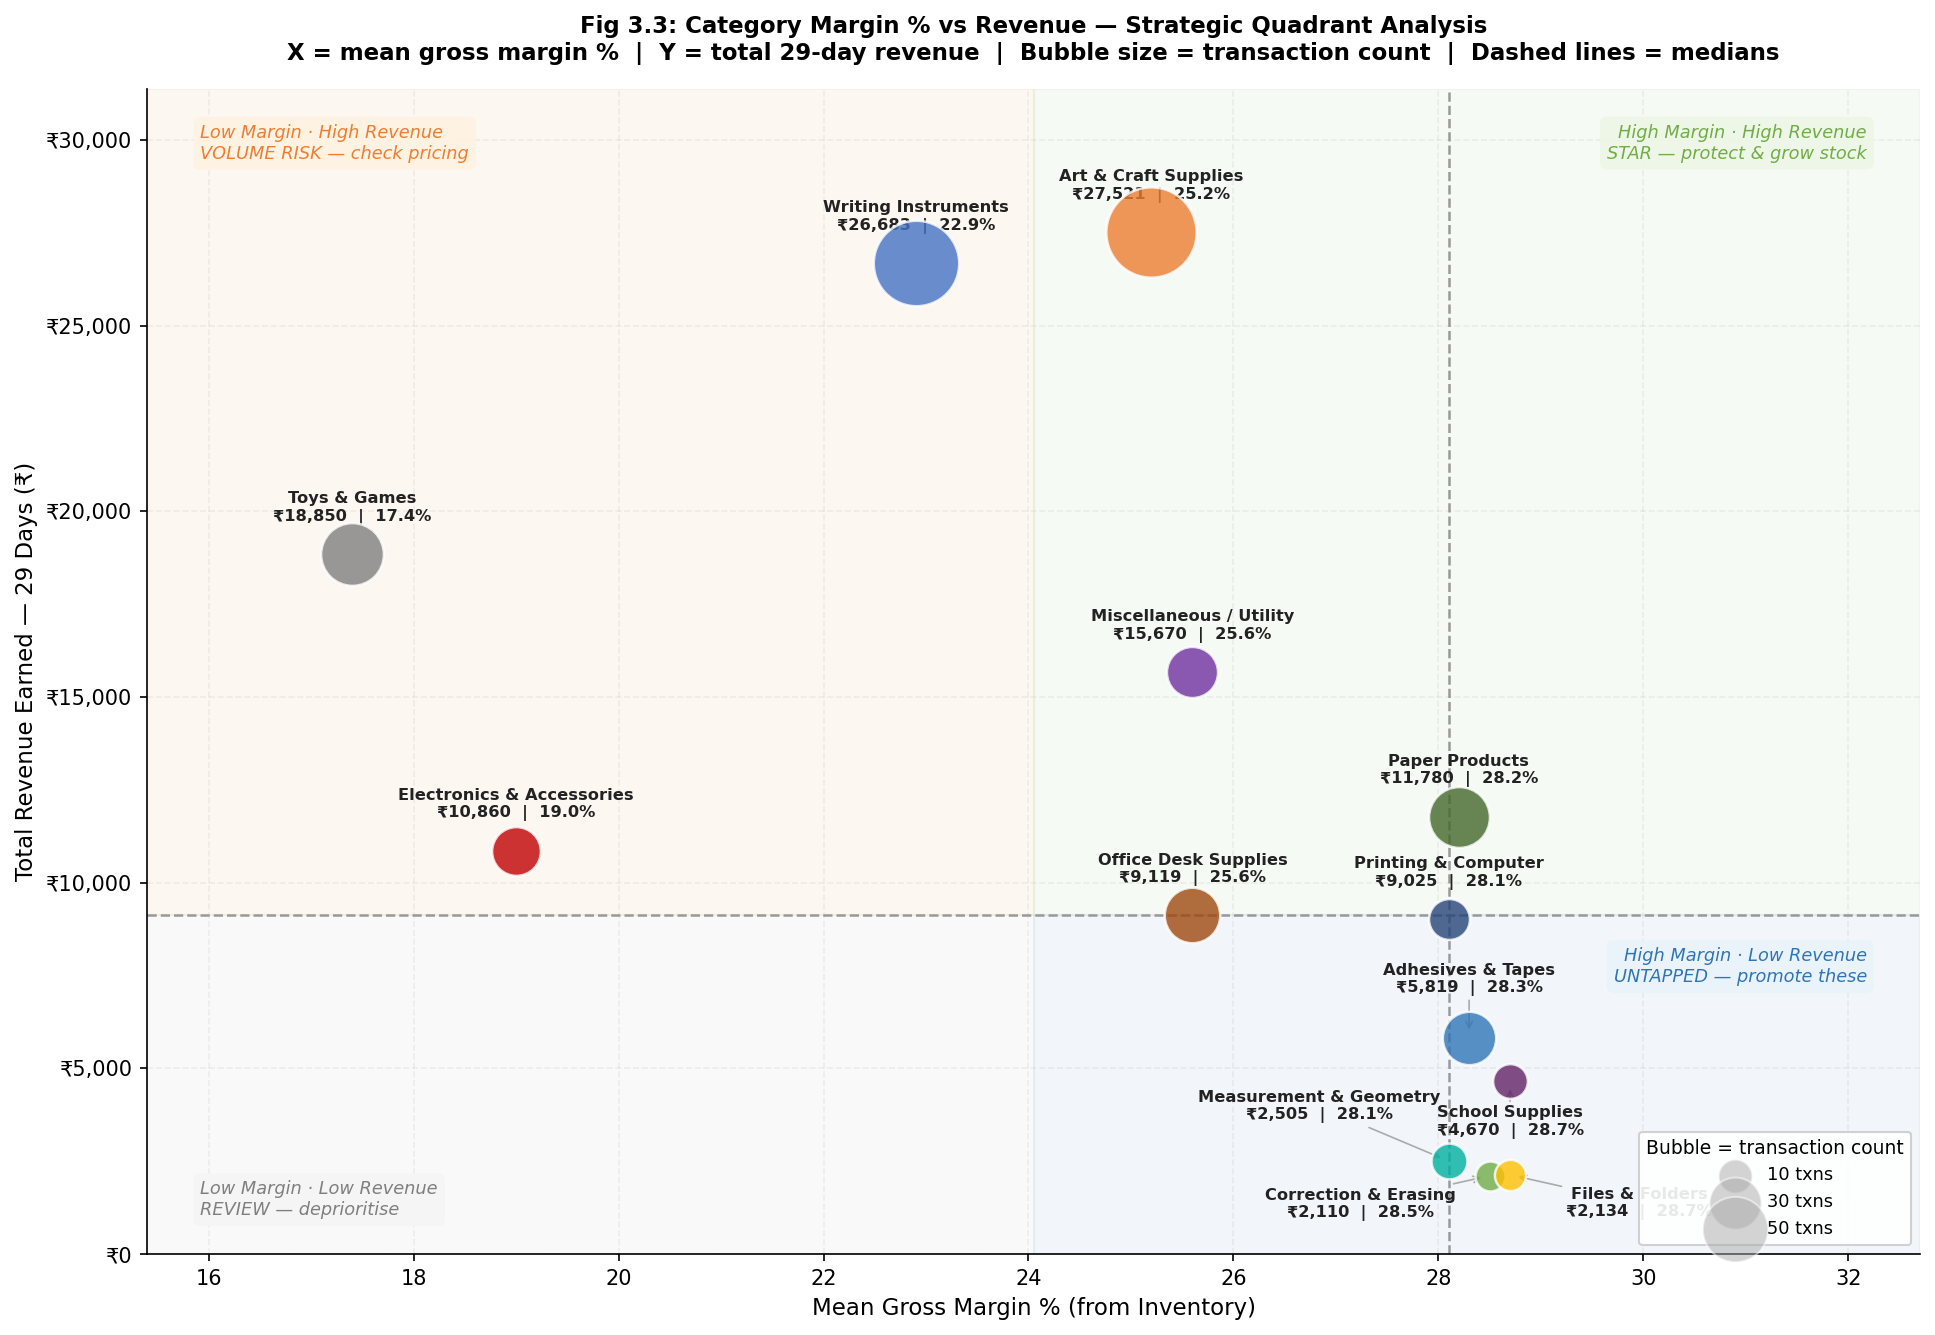

Saved: fig3_3_quadrant_margin_revenue.png


In [ ]:
# formerly 5.8

cat_margin = (inv_known[~inv_known['Category'].isin(['Services'])]
              .groupby('CatLabel')['Margin_pct'].mean().round(1))
cat_revenue = sal[sal['Category'] != 'Other'].groupby('Category')['Revenue'].sum()
cat_txns    = sal[sal['Category'] != 'Other'].groupby('Category')['Revenue'].count()

q_data = pd.DataFrame({
    'Margin (%)':   cat_margin,
    'Revenue (₹)':  cat_revenue,
    'Transactions': cat_txns,
}).dropna()

med_margin  = q_data['Margin (%)'].median()
med_revenue = q_data['Revenue (₹)'].median()

size_scale_q = 1800 / q_data['Transactions'].max()
q_data['BubbleSize'] = (q_data['Transactions'] * size_scale_q + 80).clip(lower=80)

fig, ax = plt.subplots(figsize=(13, 9))

# Quadrant shading
y_max = q_data['Revenue (₹)'].max()
x_min = q_data['Margin (%)'].min()
x_max = q_data['Margin (%)'].max()

ax.axhspan(med_revenue, y_max * 1.14, xmin=0,   xmax=0.5,  alpha=0.06, color=ORANGE)
ax.axhspan(med_revenue, y_max * 1.14, xmin=0.5,  xmax=1.0,  alpha=0.06, color=GREEN)
ax.axhspan(0,            med_revenue,  xmin=0.5,  xmax=1.0,  alpha=0.06, color=BLUE)
ax.axhspan(0,            med_revenue,  xmin=0,   xmax=0.5,  alpha=0.04, color=GRAY)

ax.axvline(med_margin,  color='#999', linestyle='--', linewidth=1.2)
ax.axhline(med_revenue, color='#999', linestyle='--', linewidth=1.2)

# ── Manual offsets for the crowded bottom-right cluster ──────────────────────
# Each entry: category → (x_offset_pts, y_offset_pts)
# Alternate above and below the dot so labels don't stack on top of each other
CLUSTER_OFFSETS = {
    'Adhesives & Tapes':        ( 0,   22),
    'School Supplies':          ( 0,  -26),
    'Measurement & Geometry':   (-62,  20),
    'Correction & Erasing':     (-62, -20),
    'Fasteners & Binding':      ( 62,  20),
    'Files & Folders':          ( 62, -20),
    'Envelopes & Mailing':      ( 0,   36),
    'Office Forms & Registers': ( 0,  -36),
}

for i, (cat, row) in enumerate(q_data.iterrows()):
    color = CAT_PALETTE[i % len(CAT_PALETTE)]
    ax.scatter(row['Margin (%)'], row['Revenue (₹)'],
               s=row['BubbleSize'], color=color, alpha=0.80,
               edgecolors='white', linewidth=1.2, zorder=4)

    xy_off = CLUSTER_OFFSETS.get(cat, (0, 16))
    use_arrow = cat in CLUSTER_OFFSETS

    ax.annotate(
        f"{cat}\n₹{row['Revenue (₹)']:,.0f}  |  {row['Margin (%)']:.1f}%",
        xy=(row['Margin (%)'], row['Revenue (₹)']),
        xytext=xy_off,
        textcoords='offset points',
        ha='center', fontsize=7.8, fontweight='bold', color='#222',
        arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.8,
                        shrinkA=0, shrinkB=4) if use_arrow else None,
    )

# ── Quadrant labels: corners via axes-fraction transform ─────────────────────
q_labels = [
    (0.03, 0.97, 'Low Margin · High Revenue\nVOLUME RISK — check pricing',
     '#FFF3E0', ORANGE, 'left', 'top'),
    (0.97, 0.97, 'High Margin · High Revenue\nSTAR — protect & grow stock',
     '#EDF7E6', GREEN,  'right', 'top'),
    (0.97, 0.23, 'High Margin · Low Revenue\nUNTAPPED — promote these',
     '#EBF3FB', BLUE,   'right', 'bottom'),
    (0.03, 0.03, 'Low Margin · Low Revenue\nREVIEW — deprioritise',
     '#F5F5F5', GRAY,   'left', 'bottom'),
]
for (ax_x, ax_y, txt, fc, tc, ha, va) in q_labels:
    ax.text(ax_x, ax_y, txt,
            transform=ax.transAxes,
            ha=ha, va=va, fontsize=8.5, color=tc, style='italic',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=fc,
                      edgecolor='none', alpha=0.88))

ax.set_xlabel('Mean Gross Margin % (from Inventory)', fontsize=11)
ax.set_ylabel('Total Revenue Earned — 29 Days (₹)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_xlim(x_min - 2, x_max + 4)
ax.set_ylim(0, y_max * 1.14)
ax.grid(True, alpha=0.18, linestyle='--')

for txns, label in [(10, '10 txns'), (30, '30 txns'), (50, '50 txns')]:
    ax.scatter([], [], s=txns * size_scale_q + 80, color='#aaa',
               alpha=0.5, edgecolors='white', label=label)
ax.legend(title='Bubble = transaction count', fontsize=8.5,
          title_fontsize=9, loc='lower right', framealpha=0.9)

ax.set_title(
    'Fig 3.3: Category Margin % vs Revenue — Strategic Quadrant Analysis\n'
    'X = mean gross margin %  |  Y = total 29-day revenue  |  '
    'Bubble size = transaction count  |  Dashed lines = medians',
    fontsize=11, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('fig3_3_quadrant_margin_revenue.png')
plt.show()
print("Saved: fig3_3_quadrant_margin_revenue.png")

# FIGURE 3.4
Bubble Chart: Category Performance — Revenue × Transactions × Units Sold
PS 1.2 — Inventory Movement Uncertainty

WHY THIS CHART: Encodes 4 variables simultaneously (X = transaction frequency,
Y = revenue, bubble size = units sold, colour = category) in a way no table
or bar chart can. Quadrant lines at medians create an instant fast-mover /
slow-mover classification without requiring any statistical test.
The numerical table below the chart addresses the feedback that the
interpretation was too qualitative.

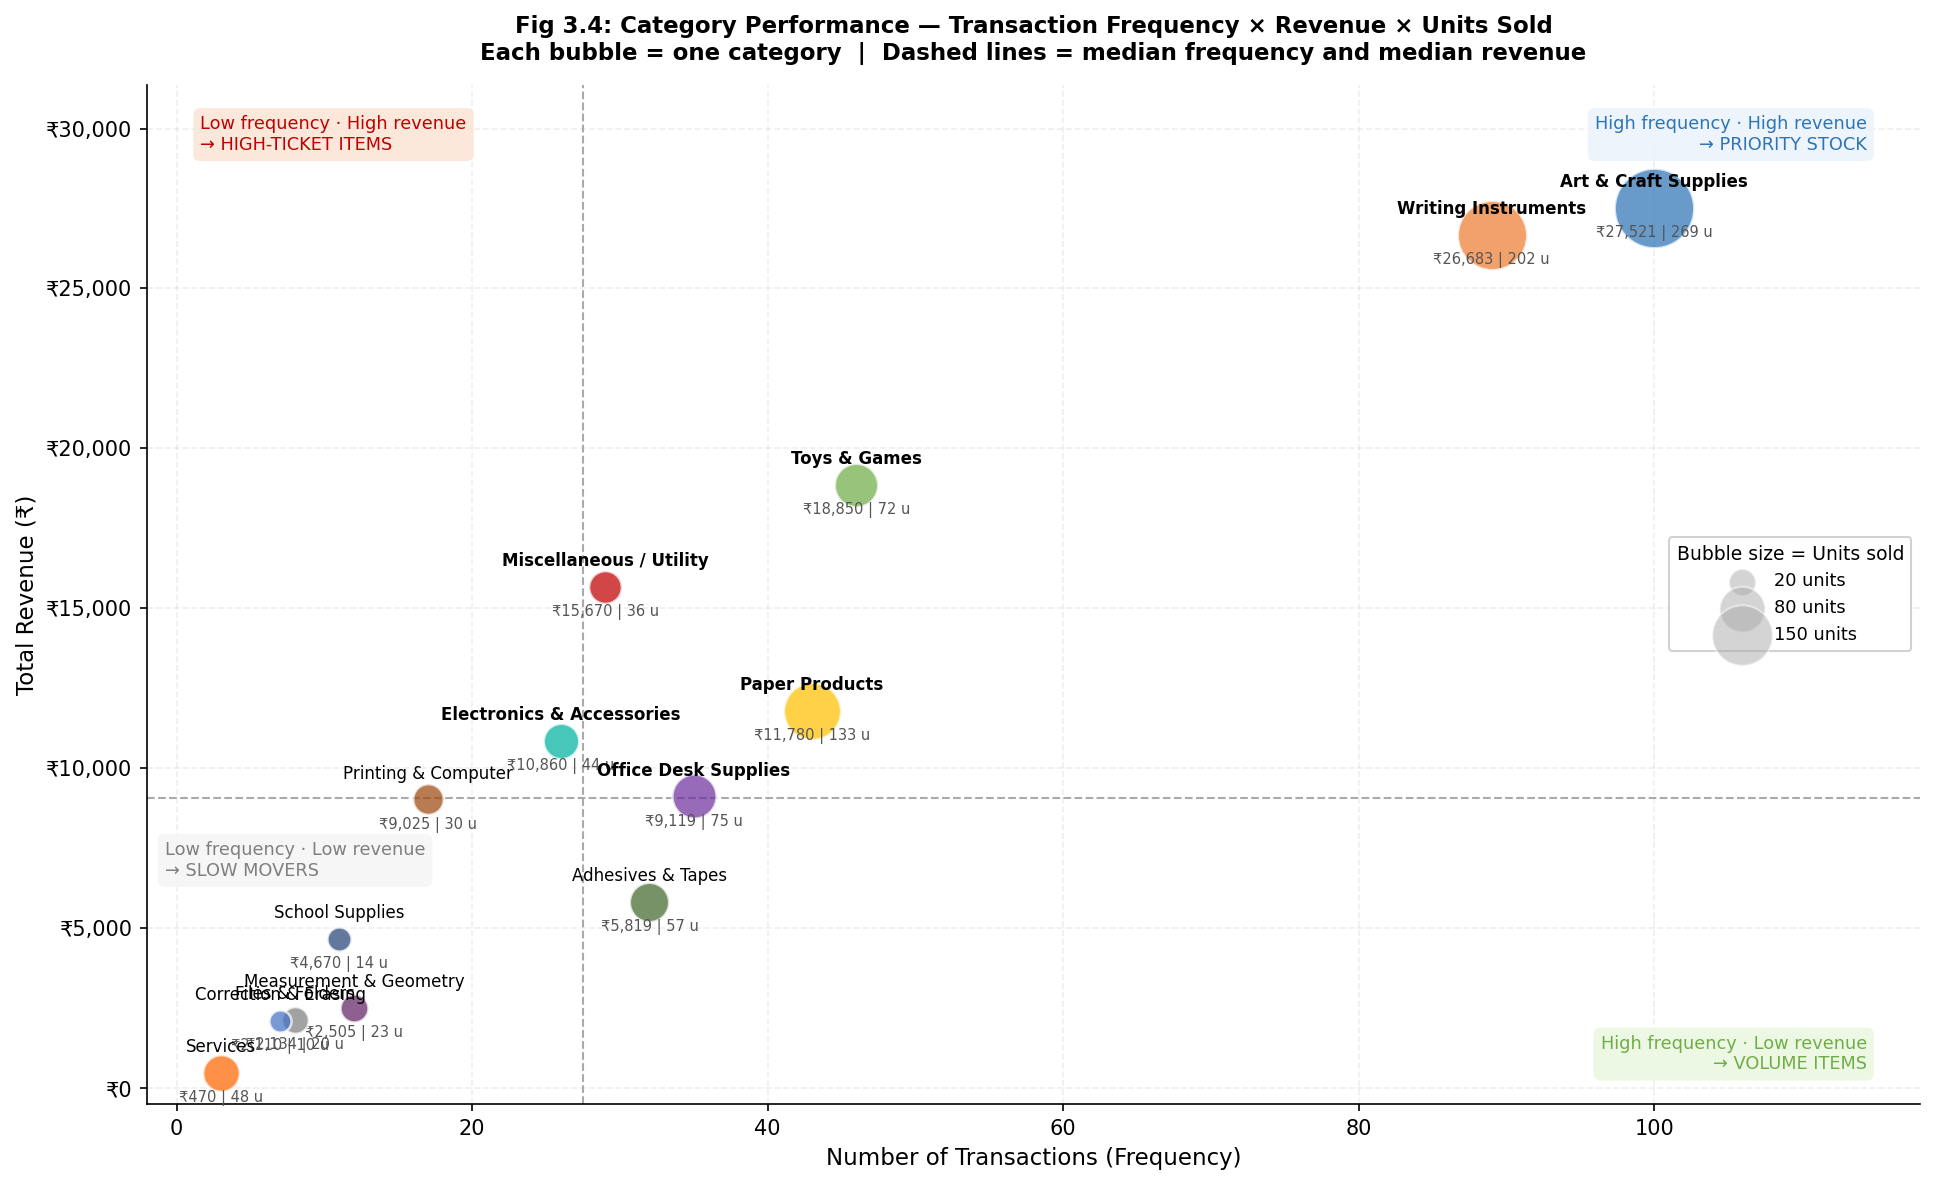

Saved: fig3_4_bubble_chart.png


In [ ]:


cat_stats = sal[sal['Category'] != 'Other'].groupby('Category').agg(
    Revenue      =('Revenue', 'sum'),
    Transactions =('Revenue', 'count'),
    Units        =('Qty_s',   'sum')
).reset_index().sort_values('Revenue', ascending=False)

size_scale = 1400 / cat_stats['Units'].max()
cat_stats['BubbleSize'] = (cat_stats['Units'] * size_scale + 60).clip(lower=60)

med_txn = cat_stats['Transactions'].median()
med_rev = cat_stats['Revenue'].median()

fig, ax = plt.subplots(figsize=(13, 8))

for i, row in cat_stats.iterrows():
    idx   = list(cat_stats['Category']).index(row['Category'])
    color = CAT_PALETTE[idx % len(CAT_PALETTE)]
    ax.scatter(row['Transactions'], row['Revenue'],
               s=row['BubbleSize'], color=color, alpha=0.72,
               edgecolors='white', linewidth=1.2, zorder=3)
    ax.annotate(
        row['Category'],
        (row['Transactions'], row['Revenue']),
        textcoords='offset points', xytext=(0, 10),
        ha='center', fontsize=8,
        fontweight='bold' if row['Revenue'] > med_rev else 'normal'
    )
    ax.annotate(
        f"₹{row['Revenue']:,.0f} | {int(row['Units'])} u",
        (row['Transactions'], row['Revenue']),
        textcoords='offset points', xytext=(0, -14),
        ha='center', fontsize=7, color='#555'
    )

ax.axvline(med_txn, color='#aaa', linestyle='--', linewidth=1)
ax.axhline(med_rev, color='#aaa', linestyle='--', linewidth=1)

ax.set_xlabel('Number of Transactions (Frequency)', fontsize=11)
ax.set_ylabel('Total Revenue (₹)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.grid(True, alpha=0.2, linestyle='--')

x_max_plot = cat_stats['Transactions'].max() * 1.18
y_max_plot = cat_stats['Revenue'].max() * 1.14
ax.set_xlim(-2, x_max_plot)
ax.set_ylim(-500, y_max_plot)

# ── Quadrant labels: pinned to the 4 corners via axes-fraction transform ──
# Each label sits just inside its corner so it never collides with data points.
corner_labels = [
    # (ax_x, ax_y, text, facecolor, textcolor, ha, va)
    (0.97, 0.97,
     'High frequency · High revenue\n→ PRIORITY STOCK',
     '#EBF3FB', '#2E75B6', 'right', 'top'),
    (0.03, 0.97,
     'Low frequency · High revenue\n→ HIGH-TICKET ITEMS',
     '#FCE4D6', '#C00000', 'left', 'top'),
    (0.97, 0.03,
     'High frequency · Low revenue\n→ VOLUME ITEMS',
     '#EBF8E1', '#70AD47', 'right', 'bottom'),
    (0.01, 0.22,
     'Low frequency · Low revenue\n→ SLOW MOVERS',
     '#F5F5F5', '#7F7F7F', 'left', 'bottom'),
]
for (ax_x, ax_y, txt, fc, tc, ha, va) in corner_labels:
    ax.text(ax_x, ax_y, txt,
            transform=ax.transAxes,
            ha=ha, va=va, fontsize=8.5,
            color=tc,
            bbox=dict(boxstyle='round,pad=0.4', facecolor=fc,
                      edgecolor='none', alpha=0.88))

for units, label in [(20, '20 units'), (80, '80 units'), (150, '150 units')]:
    ax.scatter([], [], s=units * size_scale + 60, color='#aaa',
               alpha=0.5, edgecolors='white', label=label)
ax.legend(title='Bubble size = Units sold', fontsize=8.5,
          title_fontsize=9, loc='center right', framealpha=0.9)

ax.set_title(
    'Fig 3.4: Category Performance — Transaction Frequency × Revenue × Units Sold\n'
    'Each bubble = one category  |  Dashed lines = median frequency and median revenue',
    fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig3_4_bubble_chart.png')
plt.show()
print("Saved: fig3_4_bubble_chart.png")

# FIGURE 3.5
Slope / Bump Chart: Revenue Rank vs Transaction Frequency Rank
PS 1.2 — Inventory Movement Uncertainty

WHY THIS CHART: A slope chart shows rank CHANGES between two orderings of the
same categories. When a category drops in rank from "by revenue" to "by
frequency", it means it earns a lot per transaction but sells rarely — it
needs different inventory logic than a category that is both frequent and
high-revenue. This mismatch is invisible in a simple revenue bar chart.

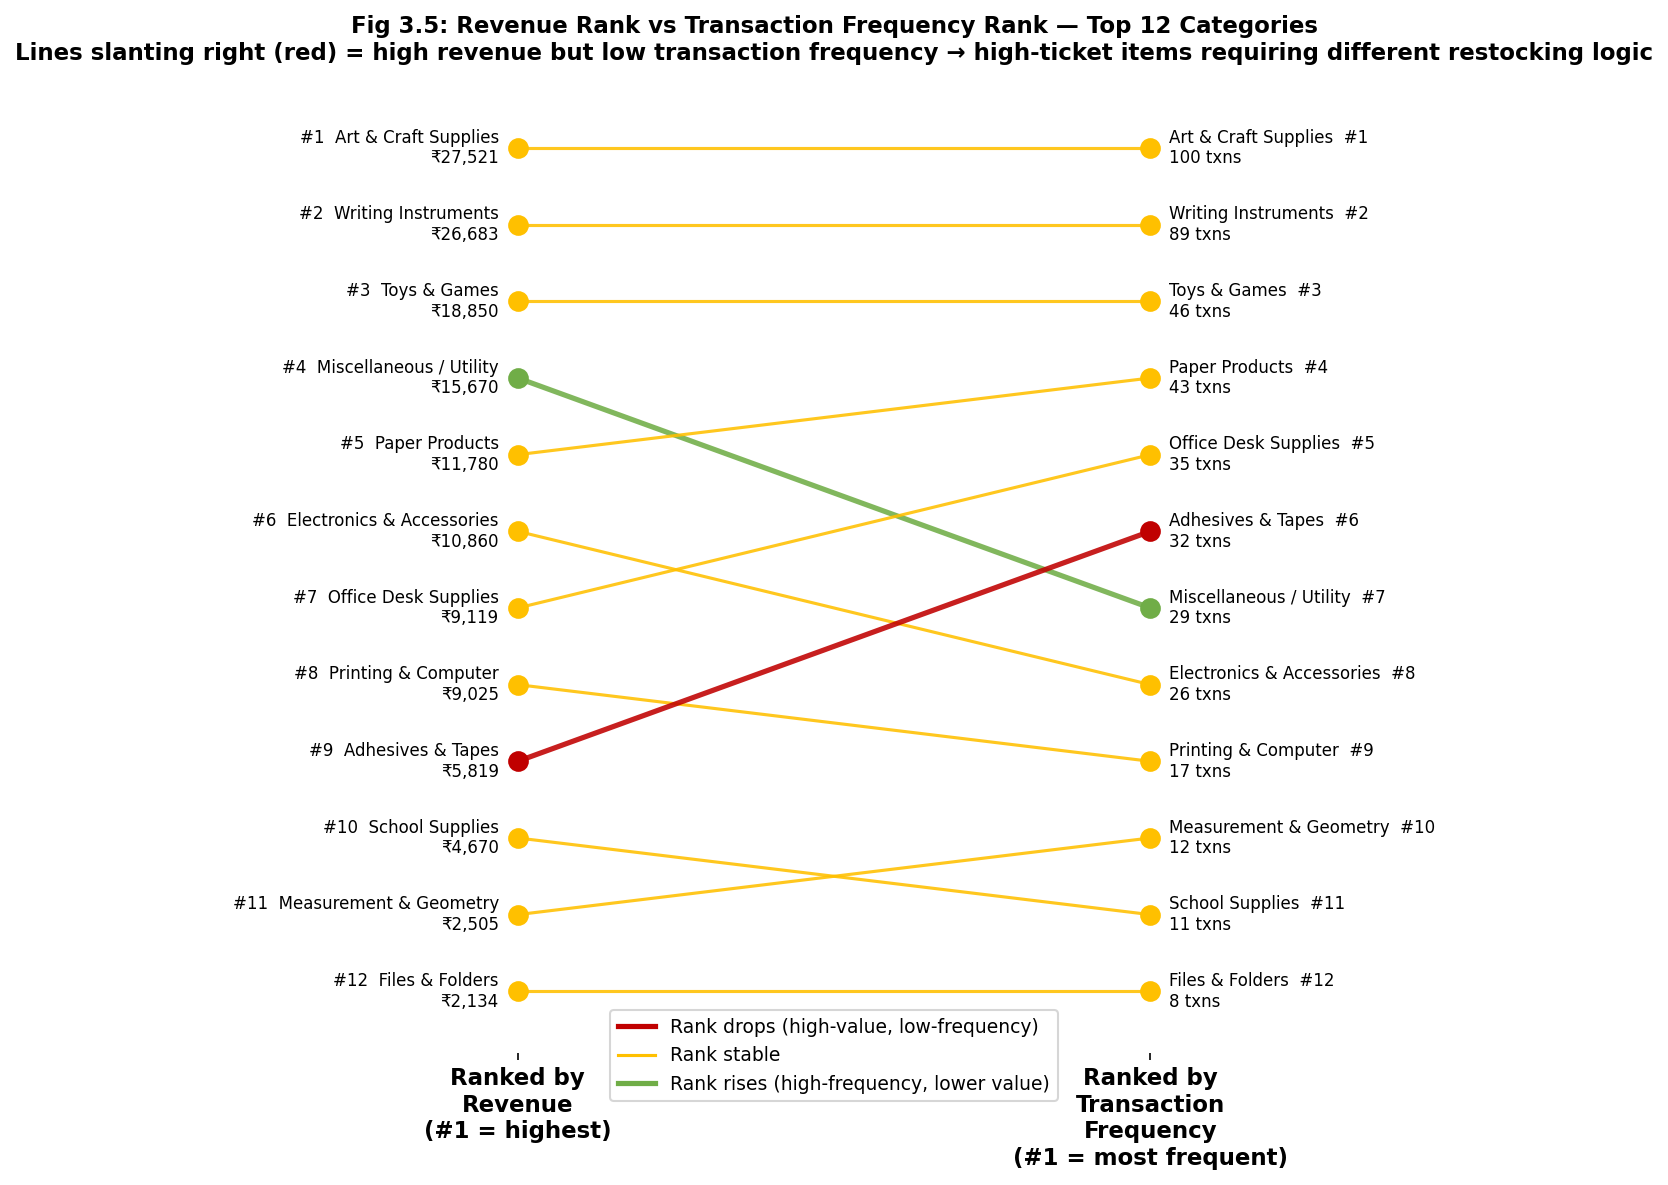

Saved: fig3_5_slope_rank.png

── Rank comparison table ───────────────────────────────────
                 Category  RevRank  Revenue (₹)  TxnRank  Transactions  Rank Δ
     Art & Craft Supplies        1        27521        1           100       0
      Writing Instruments        2        26683        2            89       0
             Toys & Games        3        18850        3            46       0
  Miscellaneous / Utility        4        15670        7            29      -3
           Paper Products        5        11780        4            43       1
Electronics & Accessories        6        10860        8            26      -2
     Office Desk Supplies        7         9119        5            35       2
      Printing & Computer        8         9025        9            17      -1
        Adhesives & Tapes        9         5819        6            32       3
          School Supplies       10         4670       11            11      -1
   Measurement & Geometry       11      

In [ ]:
# formerly 5.5

rev_rank = (sal[sal['Category'] != 'Other']
            .groupby('Category')['Revenue'].sum()
            .sort_values(ascending=False)
            .reset_index()
            .rename(columns={'Revenue': 'TotalRev'}))
txn_rank = (sal[sal['Category'] != 'Other']
            .groupby('Category')['Revenue'].count()
            .sort_values(ascending=False)
            .reset_index()
            .rename(columns={'Revenue': 'TxnCount'}))

rev_rank['RevRank'] = range(1, len(rev_rank) + 1)
txn_rank['TxnRank'] = range(1, len(txn_rank) + 1)

bump = rev_rank.merge(txn_rank, on='Category').head(12)
bump['RankDiff'] = bump['RevRank'] - bump['TxnRank']  # + = dropped in freq rank

fig, ax = plt.subplots(figsize=(10, 8))

for _, row in bump.iterrows():
    diff  = row['RankDiff']
    color = RED if diff > 2 else (GREEN if diff < -2 else GOLD)
    lw    = 2.5 if abs(diff) > 2 else 1.5

    ax.plot([0, 1], [row['RevRank'], row['TxnRank']],
            color=color, linewidth=lw, alpha=0.88, zorder=3)
    ax.scatter([0], [row['RevRank']], color=color, s=80,  zorder=5)
    ax.scatter([1], [row['TxnRank']], color=color, s=80,  zorder=5)

    # Left label: rank by revenue + actual revenue value
    ax.text(-0.03, row['RevRank'],
            f"#{row['RevRank']}  {row['Category']}\n₹{row['TotalRev']:,.0f}",
            ha='right', va='center', fontsize=8)
    # Right label: rank by frequency + actual transaction count
    ax.text(1.03, row['TxnRank'],
            f"{row['Category']}  #{row['TxnRank']}\n{int(row['TxnCount'])} txns",
            ha='left', va='center', fontsize=8)

ax.set_xlim(-0.65, 1.65)
ax.set_ylim(len(bump) + 0.8, 0.2)
ax.set_xticks([0, 1])
# FIX: clarify rank direction on x-axis
ax.set_xticklabels(['Ranked by\nRevenue\n(#1 = highest)',
                    'Ranked by\nTransaction\nFrequency\n(#1 = most frequent)'],
                   fontsize=11, fontweight='bold')

ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)

ax.legend(handles=[
    mlines.Line2D([],[],color=RED,   linewidth=2.5, label='Rank drops (high-value, low-frequency)'),
    mlines.Line2D([],[],color=GOLD,  linewidth=1.5, label='Rank stable'),
    mlines.Line2D([],[],color=GREEN, linewidth=2.5, label='Rank rises (high-frequency, lower value)'),
], fontsize=9, loc='lower center', bbox_to_anchor=(0.5, -0.06))

ax.set_title(
    'Fig 3.5: Revenue Rank vs Transaction Frequency Rank — Top 12 Categories\n'
    'Lines slanting right (red) = high revenue but low transaction frequency → '
    'high-ticket items requiring different restocking logic',
    fontsize=11, fontweight='bold', pad=13)

plt.tight_layout()
plt.savefig('fig3_5_slope_rank.png')
plt.show()
print("Saved: fig3_5_slope_rank.png")

print("\n── Rank comparison table ───────────────────────────────────")
print(bump[['Category','RevRank','TotalRev','TxnRank','TxnCount','RankDiff']]
      .rename(columns={'TotalRev':'Revenue (₹)','TxnCount':'Transactions','RankDiff':'Rank Δ'})
      .to_string(index=False))


# FIGURE 3.6
Grouped Bar + Line: Stock Value vs 29-Day Sales Revenue by Category
PS 1.3 — Experience-Based Inventory Decision Dependency

WHY THIS CHART: Comparing stock value (what has been invested) against 29-day
sales revenue (what is being recovered) reveals whether inventory allocation
matches sales reality. The velocity ratio line (sales as % of stock value)
quantifies how quickly each category is turning over — a metric that is
entirely absent from experience-based decision making.

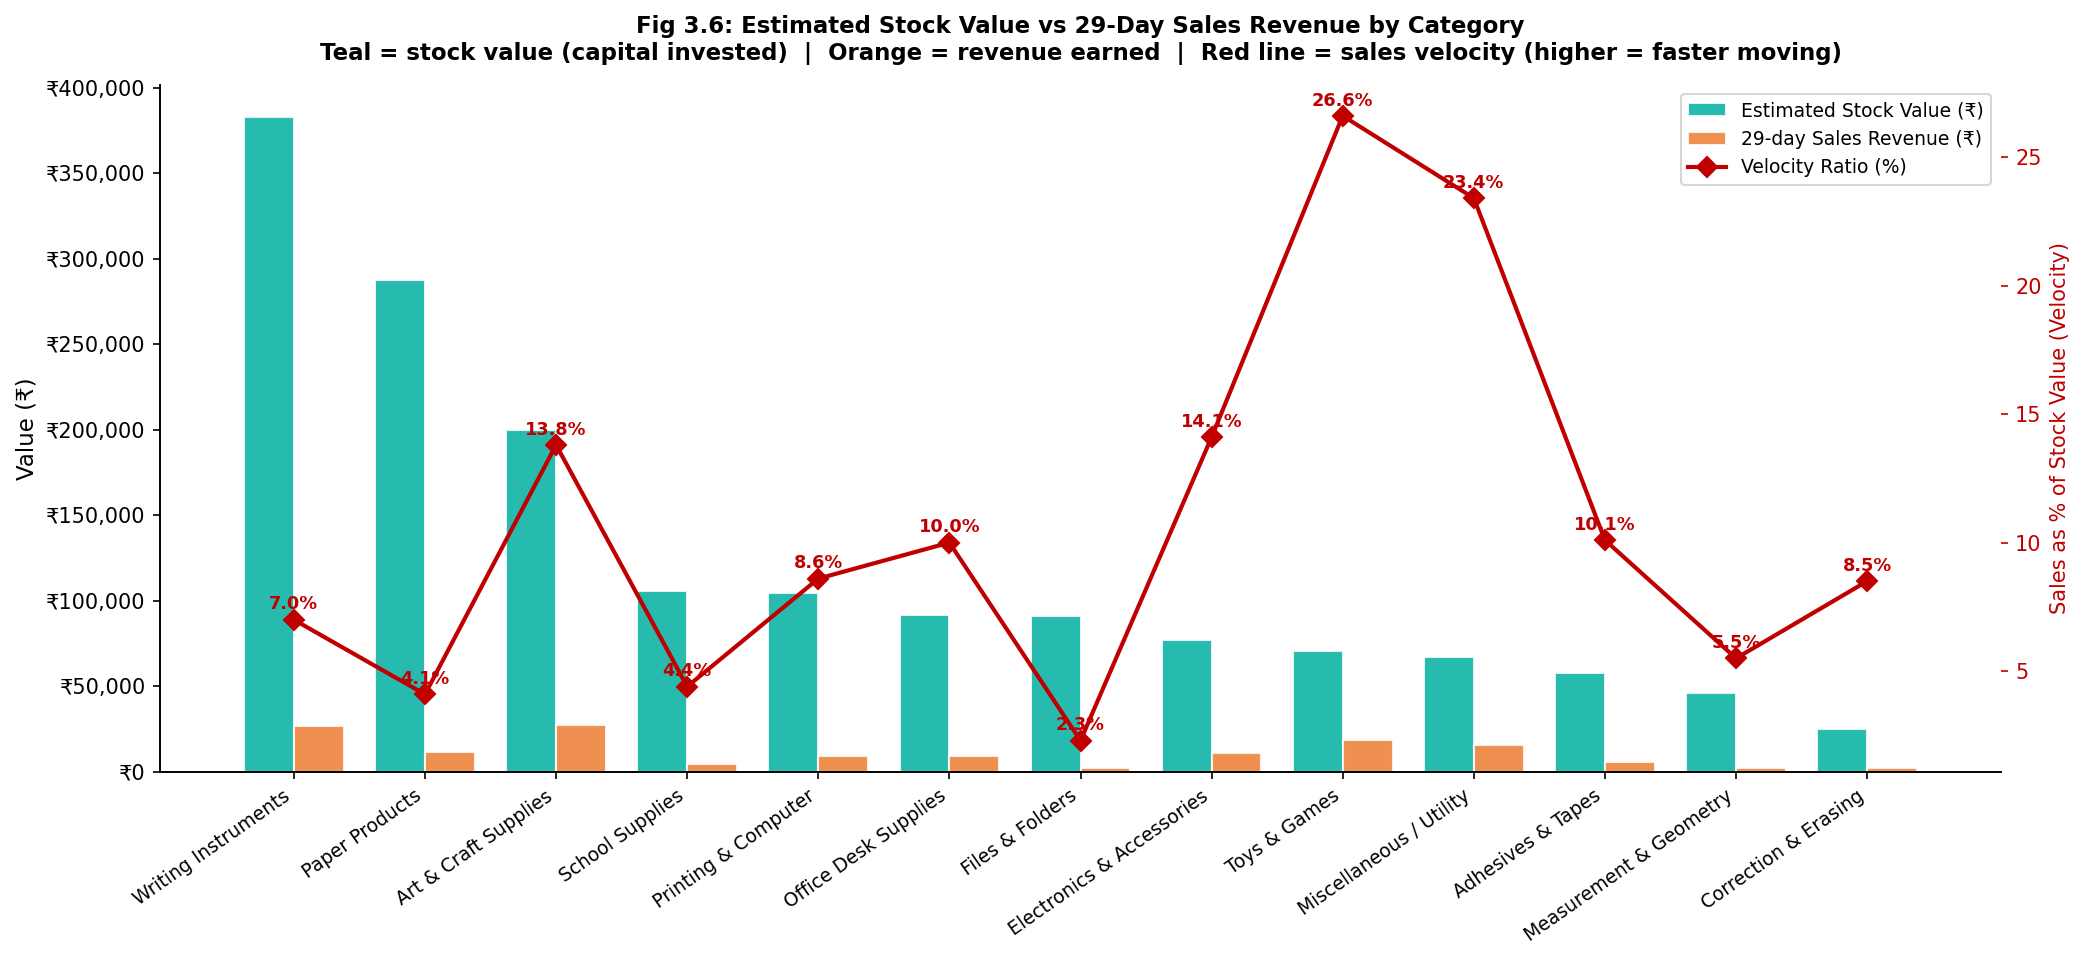

Saved: fig3_6_stock_vs_sales.png

── Stock vs Sales table ─────────────────────────────────────
                           Stock Value (₹)  Sales Revenue (₹)  Velocity (%)
Writing Instruments               382730.0            26683.0           7.0
Paper Products                    287600.0            11780.0           4.1
Art & Craft Supplies              199710.0            27521.0          13.8
School Supplies                   105650.0             4670.0           4.4
Printing & Computer               104600.0             9025.0           8.6
Office Desk Supplies               91435.0             9119.0          10.0
Files & Folders                    91300.0             2134.0           2.3
Electronics & Accessories          77100.0            10860.0          14.1
Toys & Games                       70925.0            18850.0          26.6
Miscellaneous / Utility            66875.0            15670.0          23.4
Adhesives & Tapes                  57600.0             5819.0       

In [ ]:
# formerly 5.7

inv['CatLabel2'] = inv['CatCode'].map(CAT_MAP).fillna(inv['Category'])
stock_cat  = inv[inv['Category'] != 'Services'].groupby('CatLabel2')['StockValue'].sum()
sales_cat  = sal[sal['Category'] != 'Other'].groupby('Category')['Revenue'].sum()

compare = pd.DataFrame({
    'Stock Value (₹)':   stock_cat,
    'Sales Revenue (₹)': sales_cat
}).dropna().sort_values('Stock Value (₹)', ascending=False).head(13)

compare['Velocity (%)'] = (compare['Sales Revenue (₹)'] / compare['Stock Value (₹)'] * 100).round(1)

x  = np.arange(len(compare))
w  = 0.38

fig, ax1 = plt.subplots(figsize=(14, 6.5))
ax2 = ax1.twinx()

b1 = ax1.bar(x - w/2, compare['Stock Value (₹)'],   w,
             label='Estimated Stock Value (₹)', color=TEAL,   alpha=0.85, edgecolor='white')
b2 = ax1.bar(x + w/2, compare['Sales Revenue (₹)'], w,
             label='29-day Sales Revenue (₹)',  color=ORANGE, alpha=0.85, edgecolor='white')
ax2.plot(x, compare['Velocity (%)'], color=RED, marker='D',
         linewidth=2, markersize=7, label='Velocity Ratio (%)', zorder=5)

for i, val in enumerate(compare['Velocity (%)']):
    ax2.text(i, val + 0.4, f'{val:.1f}%',
             ha='center', fontsize=8.5, color=RED, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(compare.index, rotation=35, ha='right', fontsize=9)
ax1.set_ylabel('Value (₹)', fontsize=11)
ax2.set_ylabel('Sales as % of Stock Value (Velocity)', fontsize=10, color=RED)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'₹{v:,.0f}'))
ax2.tick_params(axis='y', colors=RED)

lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, l1+l2, loc='upper right', fontsize=9)

ax1.set_title(
    'Fig 3.6: Estimated Stock Value vs 29-Day Sales Revenue by Category\n'
    'Teal = stock value (capital invested)  |  Orange = revenue earned  |  '
    'Red line = sales velocity (higher = faster moving)',
    fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig3_6_stock_vs_sales.png')
plt.show()
print("Saved: fig3_6_stock_vs_sales.png")

print("\n── Stock vs Sales table ─────────────────────────────────────")
print(compare[['Stock Value (₹)','Sales Revenue (₹)','Velocity (%)']].to_string())


## FIGURE 3.7
ABC Analysis <br>
For PS 1.2 - Inventory Movement — which SKUs deserve priority restocking attention

=== ABC Analysis Summary ===
     SKUs  SKU (%)  Revenue  Revenue (%)  Avg_Margin
ABC                                                 
A      43     24.9   102984         70.0        18.0
B      51     29.5    29406         20.0        17.6
C      79     45.7    14826         10.1        20.5

=== Tier A SKUs (top 70% of revenue) ===
       SKU                    Name                  CatLabel  Revenue  Revenue (%)  Cumulative (%)  Margin_pct
MU-CAL-001       Basic calculators   Miscellaneous / Utility    12190         8.28            8.28        19.5
PC-CPP-001         A4 copier paper       Printing & Computer     7070         4.80           13.08        18.5
AC-PNT-003          Acrylic paints      Art & Craft Supplies     5706         3.88           16.96        16.8
WI-SKC-002           Brush markers       Writing Instruments     4700         3.19           20.15        19.7
AC-CLY-001          Modelling clay      Art & Craft Supplies     4428         3.01           23.16        17.

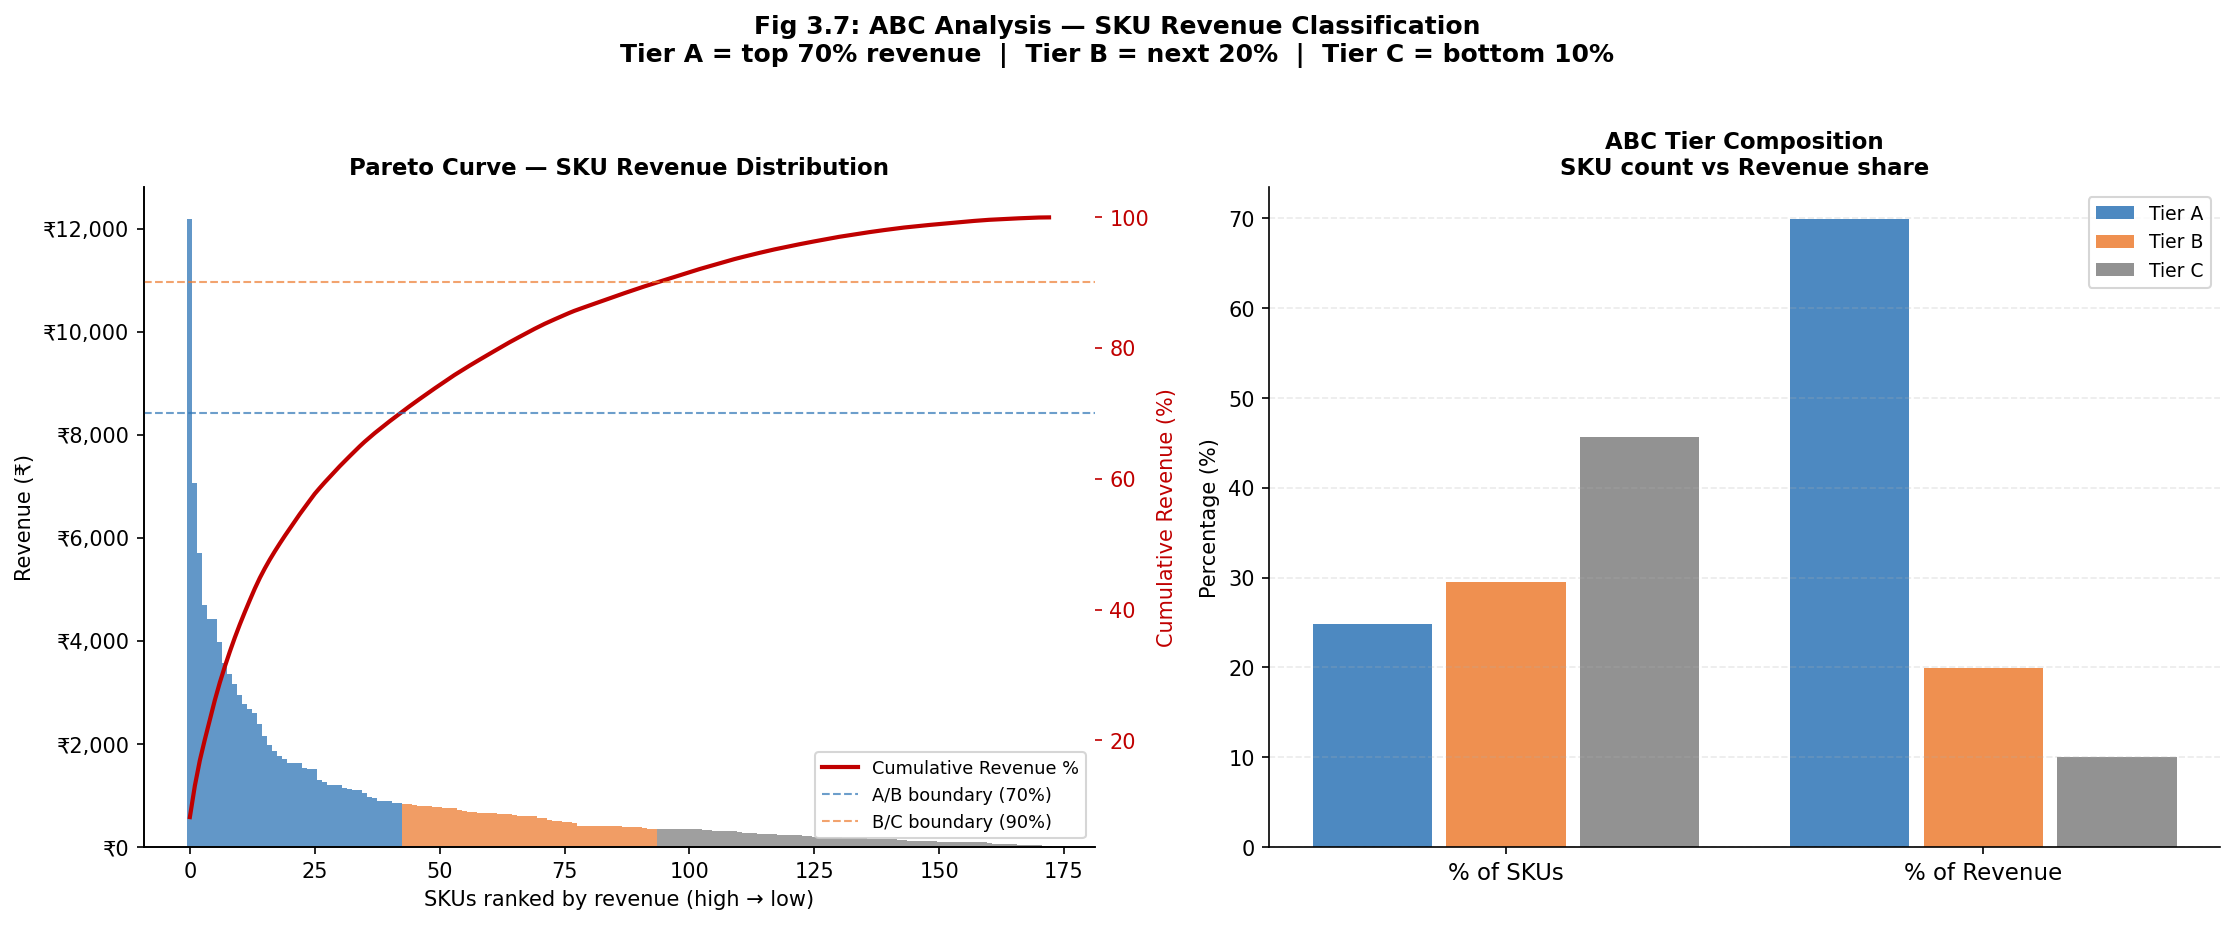

Saved: fig3_7_abc_analysis.png


In [ ]:
# Revenue per SKU across full 29-day period
sku_rev = (sal.groupby('SKU')['Revenue']
           .sum()
           .reset_index()
           .sort_values('Revenue', ascending=False))

# Cumulative revenue %
total_rev = sku_rev['Revenue'].sum()
sku_rev['Revenue (%)']    = (sku_rev['Revenue'] / total_rev * 100).round(2)
sku_rev['Cumulative (%)'] = sku_rev['Revenue (%)'].cumsum().round(2)

# Assign ABC tier
def abc_tier(cum_pct):
    if cum_pct <= 70:  return 'A'
    if cum_pct <= 90:  return 'B'
    return                     'C'

sku_rev['ABC'] = sku_rev['Cumulative (%)'].apply(abc_tier)

# Merge with inventory for context
sku_info = inv[['SKU Code', 'Name', 'CatLabel', 'Margin_pct']].rename(
    columns={'SKU Code': 'SKU'})
sku_abc = sku_rev.merge(sku_info, on='SKU', how='left')

# Summary table
summary = sku_abc.groupby('ABC').agg(
    SKUs        = ('SKU', 'count'),
    Revenue     = ('Revenue', 'sum'),
    Avg_Margin  = ('Margin_pct', 'mean')
).round(1)
summary['Revenue (%)']   = (summary['Revenue'] / total_rev * 100).round(1)
summary['SKU (%)']       = (summary['SKUs'] / len(sku_abc) * 100).round(1)
print("=== ABC Analysis Summary ===")
print(summary[['SKUs', 'SKU (%)', 'Revenue', 'Revenue (%)', 'Avg_Margin']].to_string())

# Step 6: Print A-tier SKUs (the ones that matter most)
print("\n=== Tier A SKUs (top 70% of revenue) ===")
print(sku_abc[sku_abc['ABC'] == 'A'][
    ['SKU', 'Name', 'CatLabel', 'Revenue', 'Revenue (%)', 'Cumulative (%)', 'Margin_pct']
].to_string(index=False))

# Step 7: Visualise — Pareto curve + ABC tier bars
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Pareto curve
ax1.bar(range(len(sku_rev)), sku_rev['Revenue'], color=[
    BLUE if t == 'A' else (ORANGE if t == 'B' else GRAY)
    for t in sku_rev['ABC']
], alpha=0.75, width=1.0, edgecolor='none')
ax1_r = ax1.twinx()
ax1_r.plot(range(len(sku_rev)), sku_rev['Cumulative (%)'],
           color=RED, linewidth=2, label='Cumulative Revenue %')
ax1_r.axhline(70, color=BLUE,   linestyle='--', linewidth=1, alpha=0.7, label='A/B boundary (70%)')
ax1_r.axhline(90, color=ORANGE, linestyle='--', linewidth=1, alpha=0.7, label='B/C boundary (90%)')
ax1_r.set_ylabel('Cumulative Revenue (%)', fontsize=10, color=RED)
ax1_r.tick_params(axis='y', colors=RED)
ax1_r.legend(fontsize=8.5, loc='lower right')
ax1.set_xlabel('SKUs ranked by revenue (high → low)', fontsize=10)
ax1.set_ylabel('Revenue (₹)', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:,.0f}'))
ax1.set_title('Pareto Curve — SKU Revenue Distribution', fontsize=11, fontweight='bold')

# Right: ABC summary donut-style bar
tier_summary = sku_abc.groupby('ABC').agg(SKUs=('SKU','count'), Revenue=('Revenue','sum'))
colors_abc = [BLUE, ORANGE, GRAY]
tiers = ['A', 'B', 'C']
x = np.arange(2)
for i, tier in enumerate(tiers):
    row = tier_summary.loc[tier]
    ax2.bar(0 + i*0.28 - 0.28, row['SKUs'] / len(sku_abc) * 100,
            width=0.25, color=colors_abc[i], alpha=0.85, label=f'Tier {tier}')
    ax2.bar(1 + i*0.28 - 0.28, row['Revenue'] / total_rev * 100,
            width=0.25, color=colors_abc[i], alpha=0.85)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['% of SKUs', '% of Revenue'], fontsize=11)
ax2.set_ylabel('Percentage (%)', fontsize=10)
ax2.legend(fontsize=9)
ax2.set_title('ABC Tier Composition\nSKU count vs Revenue share', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.25, linestyle='--')

plt.suptitle(
    'Fig 3.7: ABC Analysis — SKU Revenue Classification\n'
    'Tier A = top 70% revenue  |  Tier B = next 20%  |  Tier C = bottom 10%',
    fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fig3_7_abc_analysis.png', bbox_inches='tight')
plt.show()
print("Saved: fig3_7_abc_analysis.png")

## FIGURE 3.8
Days of Stock Cover Analysis <br>
PS2: Inventory Movement — how long will current stock last at current velocity?

=== Days of Stock Cover by Category ===
                           Stock Units  Daily Units Sold  Days of Stock                    Risk
Toys & Games                     265.0              2.48          106.9  Adequate (90–180 days)
Electronics & Accessories        260.0              1.52          171.1  Adequate (90–180 days)
Miscellaneous / Utility          350.0              1.24          282.3      Excess (>180 days)
Office Desk Supplies             883.0              2.59          340.9      Excess (>180 days)
Art & Craft Supplies            3200.0              9.28          344.8      Excess (>180 days)
Adhesives & Tapes               1235.0              1.97          626.9      Excess (>180 days)
Printing & Computer              779.0              1.03          756.3      Excess (>180 days)
Writing Instruments             5405.0              6.97          775.5      Excess (>180 days)
Measurement & Geometry           755.0              0.79          955.7      Excess (>180 days)


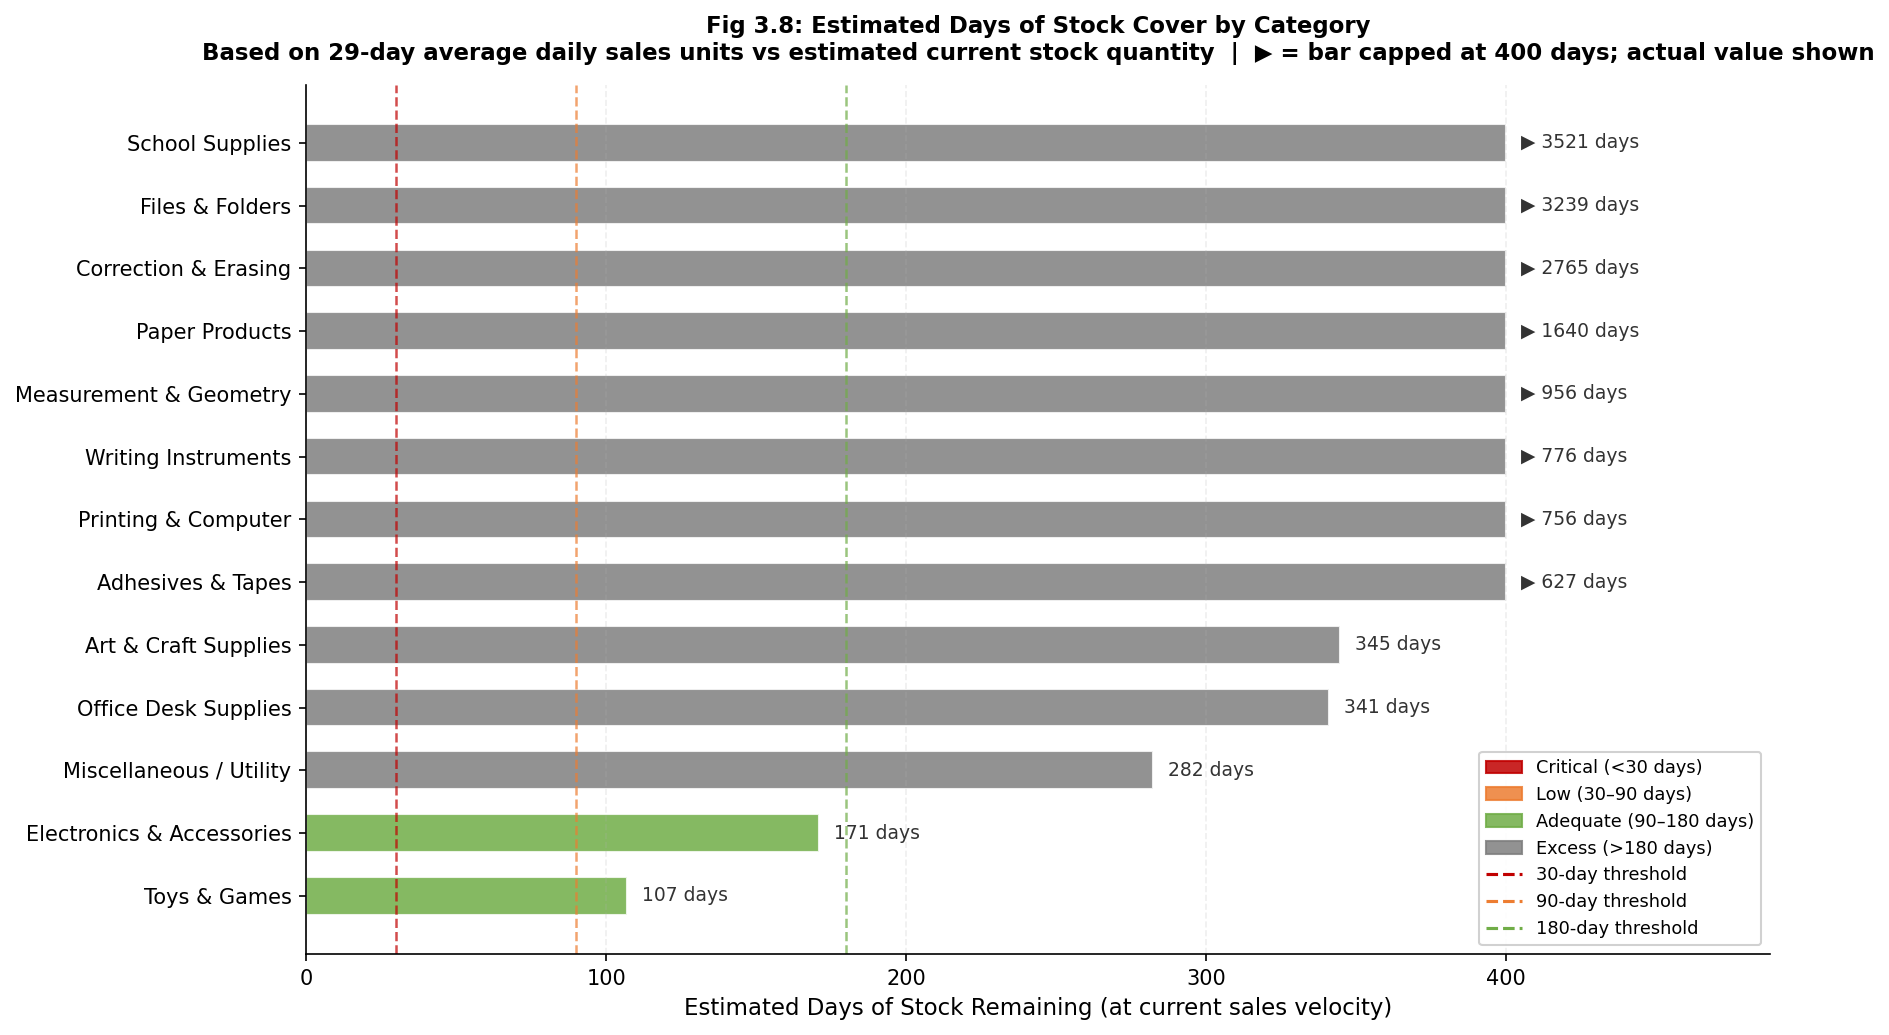

Saved: fig3_8_stock_cover.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Days of Stock Cover Analysis
# PS2: Inventory Movement — how long will current stock last at current velocity?
# ─────────────────────────────────────────────────────────────────────────────

STUDY_DAYS = 29

# Daily sales units per category (from sales data)
daily_units = (sal[sal['Category'] != 'Other']
               .groupby('Category')['Qty_s']
               .sum()
               .div(STUDY_DAYS)
               .round(2)
               .rename('Daily Units Sold'))

# Current stock units per category (from inventory)
inv['CatLabel2'] = inv['CatCode'].map(CAT_MAP).fillna(inv['Category'])
stock_units = (inv[inv['Category'] != 'Services']
               .groupby('CatLabel2')['Qty']
               .sum()
               .rename('Stock Units'))

# Combine
cover = pd.DataFrame({
    'Stock Units':      stock_units,
    'Daily Units Sold': daily_units,
}).dropna()

cover['Days of Stock'] = (cover['Stock Units'] / cover['Daily Units Sold']).round(1)

# Risk classification
def cover_risk(days):
    if days < 30:   return 'Critical (<30 days)'
    if days < 90:   return 'Low (30–90 days)'
    if days < 180:  return 'Adequate (90–180 days)'
    return                  'Excess (>180 days)'

cover['Risk'] = cover['Days of Stock'].apply(cover_risk)
cover = cover.sort_values('Days of Stock')

DISPLAY_CAP = 400
cover['Display Days'] = cover['Days of Stock'].clip(upper=DISPLAY_CAP)
cover['Capped'] = cover['Days of Stock'] > DISPLAY_CAP

RISK_COLORS = {
    'Critical (<30 days)':    RED,
    'Low (30–90 days)':       ORANGE,
    'Adequate (90–180 days)': GREEN,
    'Excess (>180 days)':     GRAY,
}

print("=== Days of Stock Cover by Category ===")
print(cover[['Stock Units', 'Daily Units Sold', 'Days of Stock', 'Risk']].to_string())

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

colors = [RISK_COLORS[r] for r in cover['Risk']]
bars = ax.barh(cover.index, cover['Display Days'],
               color=colors, alpha=0.85, edgecolor='white', height=0.6)

# Value labels — show actual value, arrow prefix if capped
for bar, (days, capped) in zip(bars, zip(cover['Days of Stock'], cover['Capped'])):
    label = f'▶ {days:.0f} days' if capped else f'{days:.0f} days'
    ax.text(min(bar.get_width() + 5, DISPLAY_CAP + 5),
            bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=9, color='#333')

# Reference lines
ax.axvline(30,  color=RED,    linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(90,  color=ORANGE, linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(180, color=GREEN,  linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_xlabel('Estimated Days of Stock Remaining (at current sales velocity)', fontsize=11)
ax.set_xlim(0, DISPLAY_CAP * 1.22)
ax.grid(axis='x', alpha=0.2, linestyle='--')

ax.set_title(
    'Fig 3.8: Estimated Days of Stock Cover by Category\n'
    'Based on 29-day average daily sales units vs estimated current stock quantity  |  '
    '▶ = bar capped at 400 days; actual value shown',
    fontsize=11, fontweight='bold', pad=12)

# Legend
legend_patches = [mpatches.Patch(color=c, label=r, alpha=0.85)
                  for r, c in RISK_COLORS.items()]
legend_lines = [
    mlines.Line2D([], [], color=RED,    linestyle='--', label='30-day threshold'),
    mlines.Line2D([], [], color=ORANGE, linestyle='--', label='90-day threshold'),
    mlines.Line2D([], [], color=GREEN,  linestyle='--', label='180-day threshold'),
]
ax.legend(handles=legend_patches + legend_lines,
          fontsize=8.5, loc='lower right', framealpha=0.9)

plt.tight_layout()
plt.savefig('fig3_8_stock_cover.png', bbox_inches='tight')
plt.show()
print("Saved: fig3_8_stock_cover.png")

# FIGURE 3.9
Heatmap: Transactions by Date × Time of Day
PS 1.3 — Experience-Based Inventory Decision Dependency

WHY THIS CHART: A heatmap is the most effective way to show a two-dimensional
pattern over time. Unlike a line chart (which would require 4 overlapping
lines), the heatmap lets the reader immediately identify consistent dark rows
(reliable peaks) vs. erratic rows (unpredictable periods) without reading
individual values.

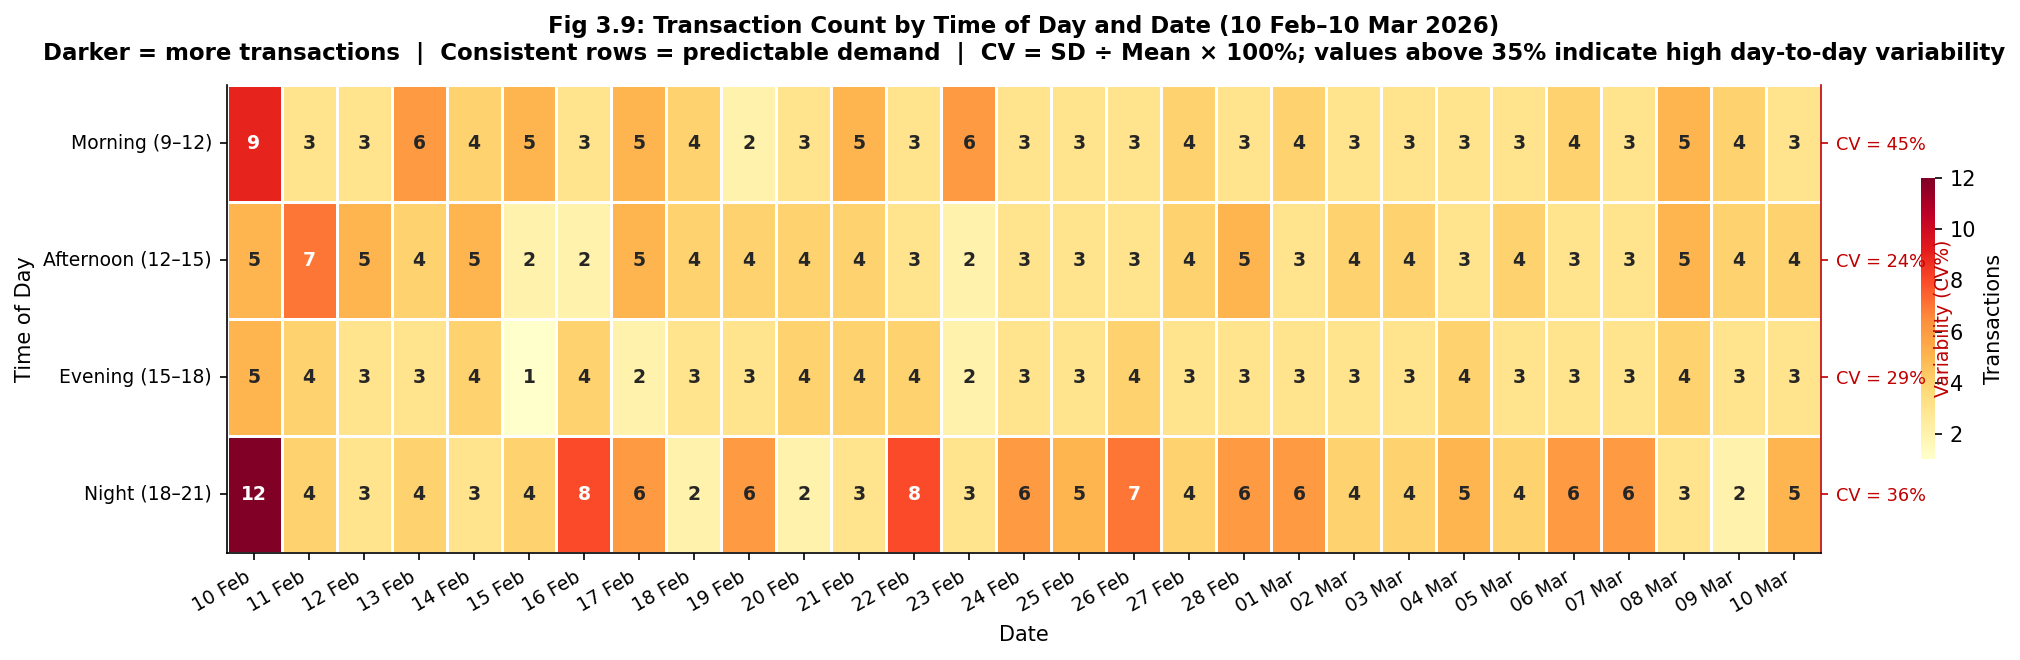

Saved: fig3_9_heatmap_tod.png

Coefficient of Variation (CV%) by time slot:
  Morning (9–12)           : CV = 36.4%  (mean=3.9, range 2–9)
  Afternoon (12–15)        : CV = 28.8%  (mean=3.8, range 2–7)
  Evening (15–18)          : CV = 24.3%  (mean=3.2, range 1–5)
  Night (18–21)            : CV = 44.6%  (mean=4.9, range 2–12)


In [ ]:
# formerly 5.3

pivot = sal.pivot_table(
    index='TimeOfDay', columns='DayLabel',
    values='Revenue', aggfunc='count', fill_value=0
)
pivot = pivot.reindex(index=TOD_ORDER, columns=date_order, fill_value=0)

# Row-level stats for annotation
row_cv = (pivot.std(axis=1) / pivot.mean(axis=1) * 100).round(1)  # coefficient of variation

fig, ax = plt.subplots(figsize=(15, 4.5))
sns.heatmap(
    pivot, ax=ax,
    cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    annot=True, fmt='d',
    annot_kws={'size': 9, 'weight': 'bold'},
    cbar_kws={'label': 'Transactions', 'shrink': 0.6}
)

# FIX: add CV definition to title
ax.set_title(
    'Fig 3.9: Transaction Count by Time of Day and Date (10 Feb–10 Mar 2026)\n'
    'Darker = more transactions  |  Consistent rows = predictable demand  |  '
    'CV = SD ÷ Mean × 100%; values above 35% indicate high day-to-day variability',
    fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Time of Day', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# Variability annotation on right side
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks([0.5, 1.5, 2.5, 3.5])
ax2.set_yticklabels(
    [f'CV = {row_cv[tod]:.0f}%' for tod in TOD_ORDER[::-1]],
    fontsize=8.5, color=RED
)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(RED)
ax2.tick_params(axis='y', colors=RED)
ax2.set_ylabel('Variability (CV%)', fontsize=9, color=RED)

plt.tight_layout()
plt.savefig('fig3_9_heatmap_tod.png')
plt.show()
print("Saved: fig3_9_heatmap_tod.png")
print(f"\nCoefficient of Variation (CV%) by time slot:")
for tod in TOD_ORDER:
    print(f"  {tod:<25}: CV = {row_cv[tod]:.1f}%  (mean={pivot.loc[tod].mean():.1f}, "
          f"range {pivot.loc[tod].min()}–{pivot.loc[tod].max()})")


# FIG 3.10
Scatter: Margin % vs Units Sold per SKU (only SKUs that appeared in sales)
PS 1.1 — "Are we selling the right products?"

WHY THIS CHART: Fig 3.1 shows all 664 SKUs. Fig 3.3 filters to only the
SKUs that actually sold during the study period, then plots each one at
(units sold, margin %). This directly answers whether the products customers
are buying most are the high-margin ones or the low-margin ones. A cluster
of high-volume, low-margin dots is an actionable pricing warning.

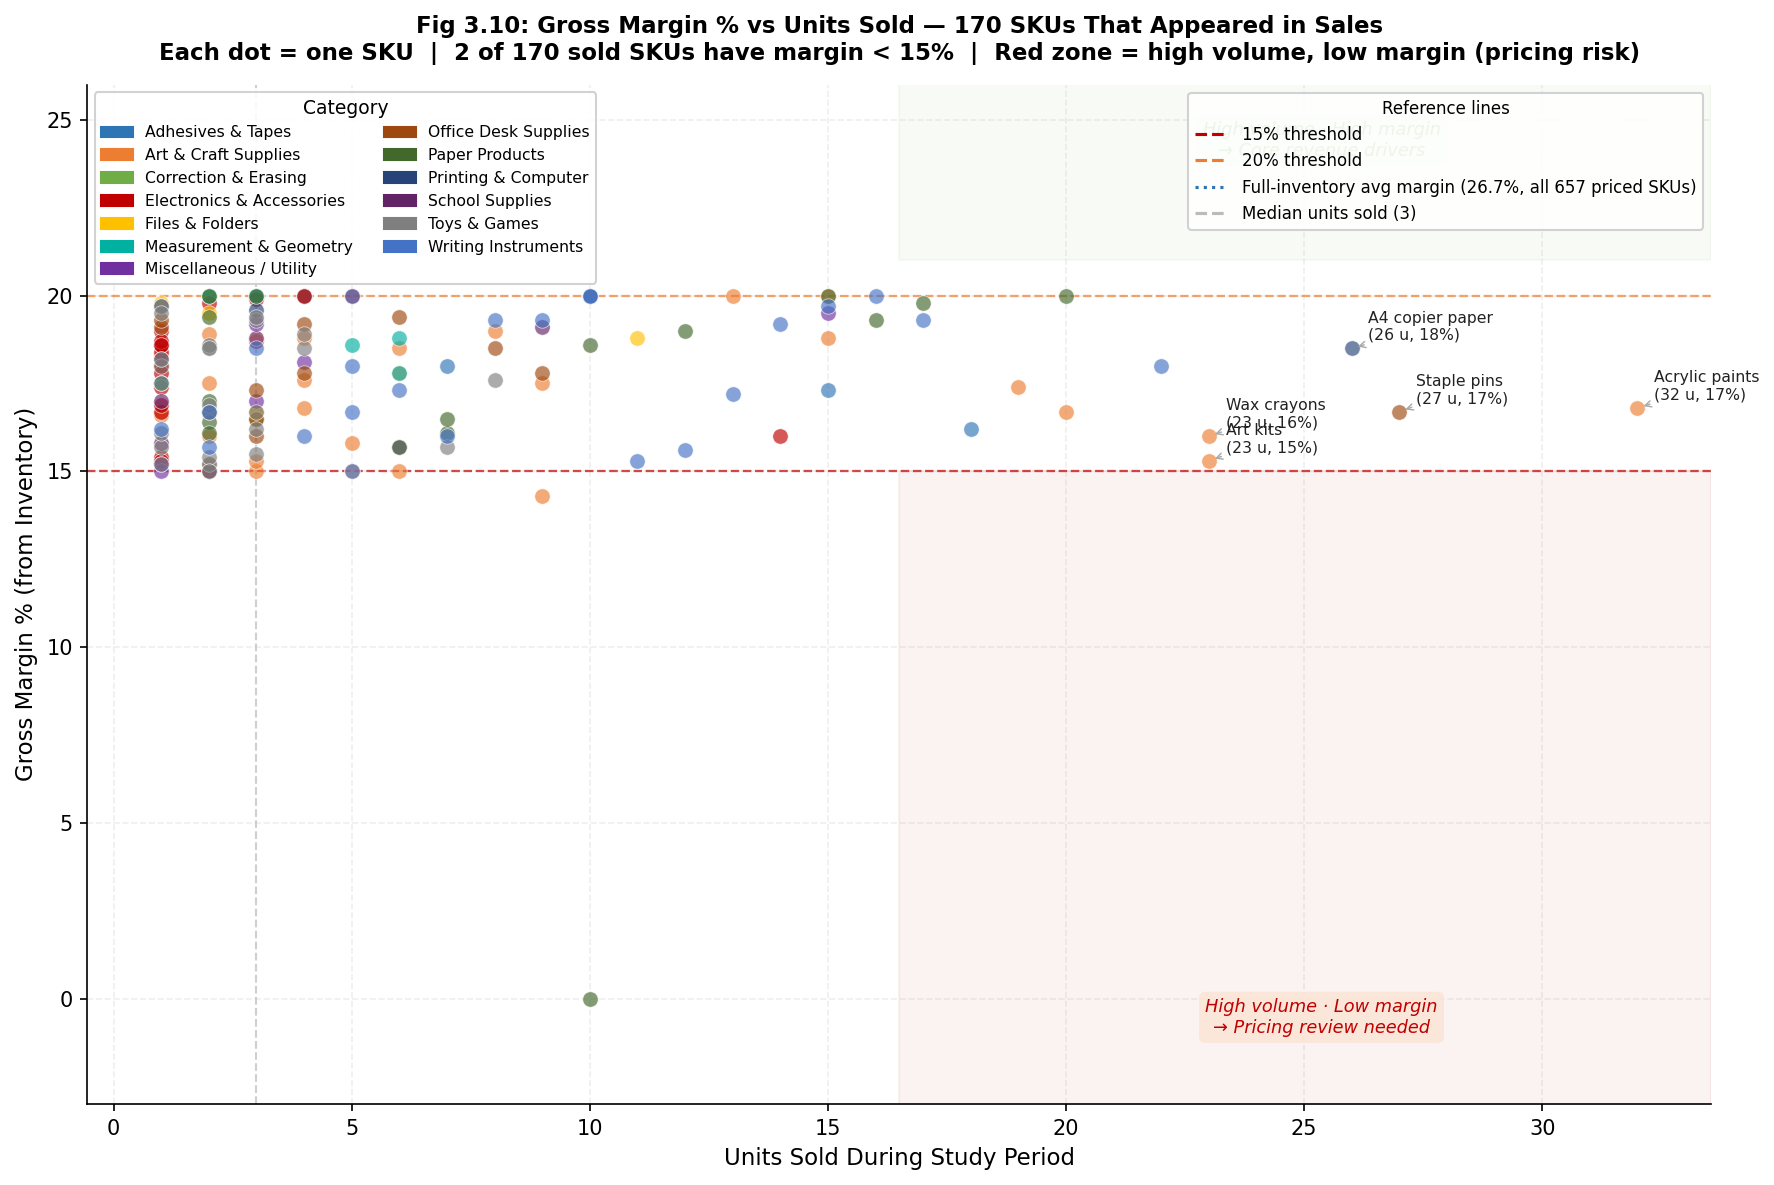

Saved: fig3_10_margin_vs_units_sold.png

SKUs sold with margin < 15% (2 items):
           Name             CatLabel  UnitsSold  Margin_pct  Revenue
Paper envelopes       Paper Products         10         0.0       20
 Glitter powder Art & Craft Supplies          9        14.3       63


In [ ]:
# formerly 5.9

  # Units sold per SKU from sales data
sku_units = sal.groupby('SKU').agg(
    UnitsSold =('Qty_s', 'sum'),
    Revenue   =('Revenue', 'sum'),
    TxnCount  =('Revenue', 'count')
).reset_index()

# Merge with inventory margin data
sku_margin = inv_known[['SKU Code', 'Name', 'Margin_pct', 'CatLabel']].copy()
sku_margin = sku_margin.rename(columns={'SKU Code': 'SKU'})

merged = sku_units.merge(sku_margin, on='SKU', how='inner')
merged = merged.dropna(subset=['Margin_pct', 'UnitsSold'])
merged = merged[merged['UnitsSold'] > 0]

# Reference lines
avg_margin   = inv_known['Margin_pct'].mean()
med_units    = merged['UnitsSold'].median()

fig, ax = plt.subplots(figsize=(12, 8))

# Draw reference lines first (behind dots)
ax.axhline(15,          color=RED,    linestyle='--', linewidth=1.1,
           alpha=0.7,   label='15% margin (lower assumed threshold)')
ax.axhline(20,          color=ORANGE, linestyle='--', linewidth=1.1,
           alpha=0.7,   label='20% margin (upper assumed threshold)')
ax.axhline(avg_margin,  color=BLUE,   linestyle=':',  linewidth=1.2,
           alpha=0.7,   label=f'Inventory avg margin ({avg_margin:.1f}%)')
ax.axvline(med_units,   color='#bbb', linestyle='--', linewidth=1,
           alpha=0.7,   label=f'Median units sold ({med_units:.0f})')

# Shade the danger zone: high units sold, margin < 15%
ax.axhspan(-5, 15, xmin=0.5, xmax=1.0,
           color=RED, alpha=0.05, zorder=1)
ax.text(0.76, 0.07,
        'High volume · Low margin\n→ Pricing review needed',
        transform=ax.transAxes, fontsize=8.5,
        color=RED, ha='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#FCE4D6',
                  edgecolor='none', alpha=0.85))

# Shade the ideal zone: high units + high margin
ax.axhspan(avg_margin, merged['Margin_pct'].max() * 1.05,
           xmin=0.5, xmax=1.0,
           color=GREEN, alpha=0.05, zorder=1)
ax.text(0.76, 0.93,
        'High volume · High margin\n→ Core revenue drivers',
        transform=ax.transAxes, fontsize=8.5,
        color=GREEN, ha='center', style='italic',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#EDF7E6',
                  edgecolor='none', alpha=0.85))

cats_sorted_m = sorted(merged['CatLabel'].dropna().unique())
cat_color_map_m = {c: CAT_PALETTE[i % len(CAT_PALETTE)]
                   for i, c in enumerate(cats_sorted_m)}

for _, row in merged.iterrows():
    color = cat_color_map_m.get(row['CatLabel'], '#888')
    ax.scatter(row['UnitsSold'], row['Margin_pct'],
               color=color, alpha=0.65, s=55,
               edgecolors='white', linewidth=0.4, zorder=3)

# Annotate top 5 by units sold
top_vol = merged.nlargest(5, 'UnitsSold')
for _, row in top_vol.iterrows():
    ax.annotate(
        f"{row['Name'][:22]}\n({int(row['UnitsSold'])} u, {row['Margin_pct']:.0f}%)",
        xy=(row['UnitsSold'], row['Margin_pct']),
        xytext=(8, 4), textcoords='offset points',
        fontsize=7.5, color='#222',
        arrowprops=dict(arrowstyle='->', color='#aaa', lw=0.7,
                        shrinkA=0, shrinkB=3)
    )

# Category colour legend (2 columns to save space)
patches = [mpatches.Patch(color=cat_color_map_m[c], label=c)
           for c in cats_sorted_m]
ax.legend(handles=patches, title='Category', title_fontsize=9,
          fontsize=7.5, ncol=2, loc='upper left', framealpha=0.88)

ax.set_xlabel('Units Sold During Study Period', fontsize=11)
ax.set_ylabel('Gross Margin % (from Inventory)', fontsize=11)
ax.set_ylim(merged['Margin_pct'].min() - 3, merged['Margin_pct'].max() + 6)
ax.grid(True, alpha=0.2, linestyle='--')

# Second legend for reference lines
# FIX: distinguish full-inventory average from sold-SKU population in legend
ref_handles = [
    mlines.Line2D([], [], color=RED,    linestyle='--', label='15% threshold'),
    mlines.Line2D([], [], color=ORANGE, linestyle='--', label='20% threshold'),
    mlines.Line2D([], [], color=BLUE,   linestyle=':',
                  label=f'Full-inventory avg margin ({avg_margin:.1f}%, all {len(inv_known)} priced SKUs)'),
    mlines.Line2D([], [], color='#bbb', linestyle='--', label=f'Median units sold ({med_units:.0f})'),
]
leg2 = ax.legend(handles=ref_handles, fontsize=8, loc='upper right',
                 framealpha=0.88, title='Reference lines', title_fontsize=8)
ax.add_artist(leg2)
# Re-add category legend so both show
ax.legend(handles=patches, title='Category', title_fontsize=9,
          fontsize=7.5, ncol=2, loc='upper left', framealpha=0.88)

n_below15_sold = (merged['Margin_pct'] < 15).sum()
n_total_sold   = len(merged)

ax.set_title(
    f'Fig 3.10: Gross Margin % vs Units Sold — {n_total_sold} SKUs That Appeared in Sales\n'
    f'Each dot = one SKU  |  {n_below15_sold} of {n_total_sold} sold SKUs have margin < 15%  |  '
    'Red zone = high volume, low margin (pricing risk)',
    fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig3_10_margin_vs_units_sold.png')
plt.show()
print("Saved: fig3_10_margin_vs_units_sold.png")

below15_sold = merged[merged['Margin_pct'] < 15].sort_values('UnitsSold', ascending=False)
print(f"\nSKUs sold with margin < 15% ({len(below15_sold)} items):")
print(below15_sold[['Name', 'CatLabel', 'UnitsSold', 'Margin_pct', 'Revenue']]
      .to_string(index=False))

# FIGURE 3.11 - Not included in the report
Diverging Bar: Cash vs UPI Revenue per Day
PS 1.3 — Experience-Based Inventory Decision Dependency

WHY THIS CHART: A standard stacked bar shows totals but makes proportional
comparison hard. A diverging bar — cash extending right, UPI extending left —
makes it immediately visible whether high-revenue days are driven by one mode,
and whether the Cash/UPI split is consistent or shifts across the period.
This is a customer behaviour pattern the owner cannot track without records.

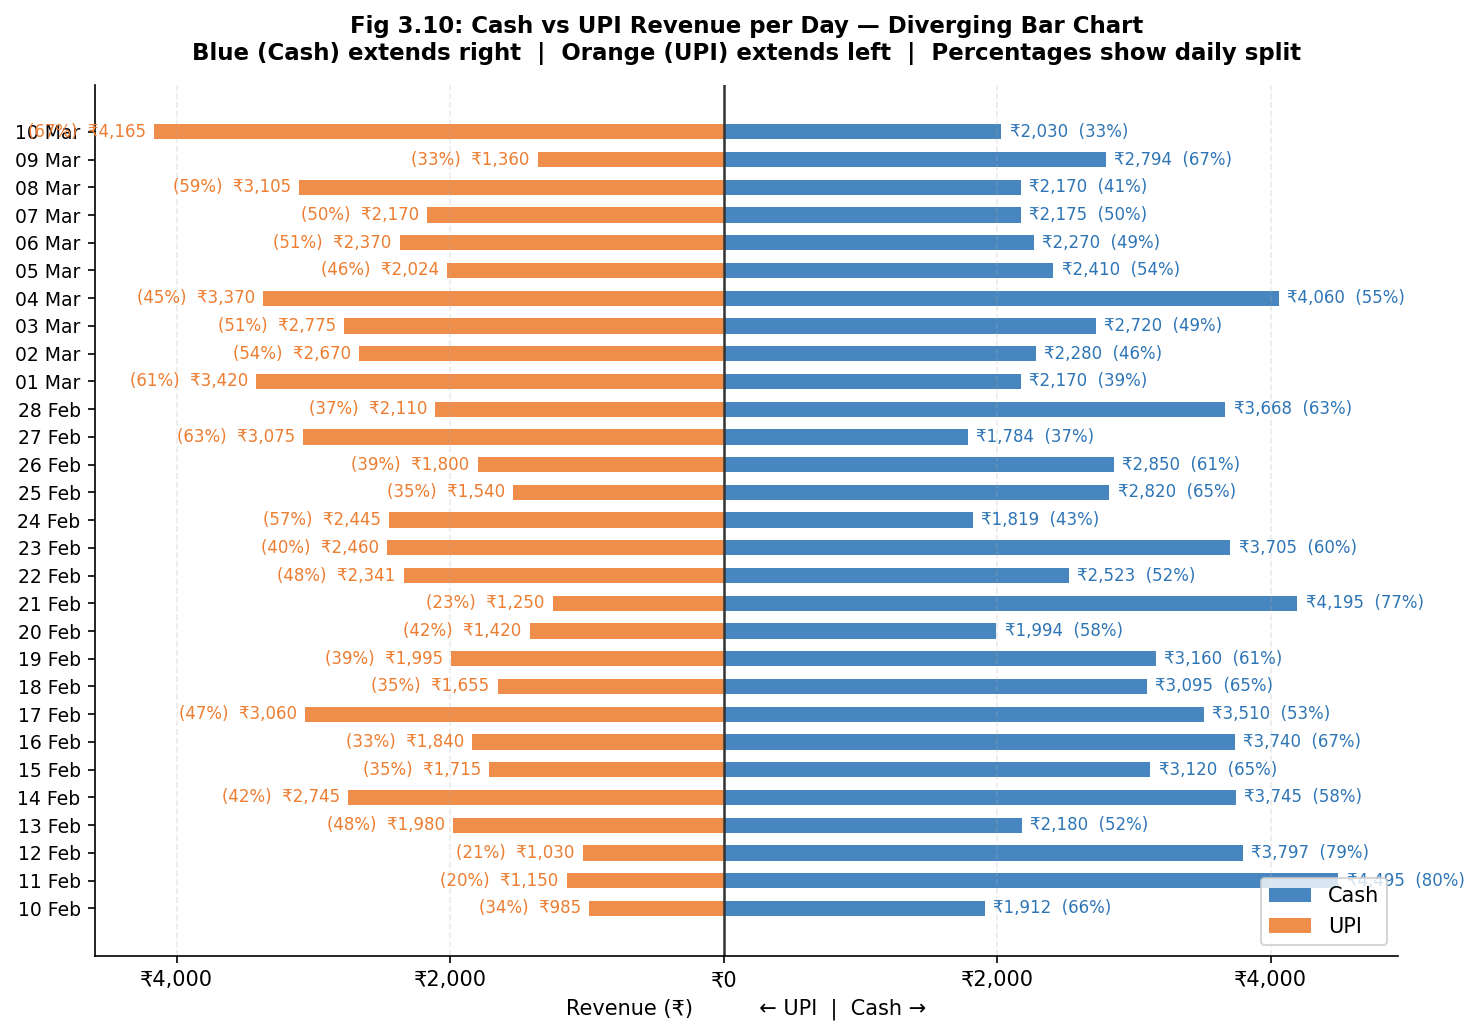

Saved: fig3_11_diverging_cash_upi.png

Overall Cash: 56.5%  |  UPI: 43.5%
Most Cash-dominant day: 11 Feb (80% cash)
Most UPI-dominant day:  10 Mar  (67% UPI)


In [ ]:
# formerly 5.6
# on standby - will be added only if there isn't enough content

pay_daily = (sal.groupby(['DayLabel', 'Mode of Payment'])['Revenue']
             .sum().unstack(fill_value=0))
for col in ['Cash', 'UPI']:
    if col not in pay_daily.columns:
        pay_daily[col] = 0
pay_daily = pay_daily.reindex(date_order)
pay_daily['Total'] = pay_daily['Cash'] + pay_daily['UPI']
pay_daily['UPI_pct']  = (pay_daily['UPI']  / pay_daily['Total'] * 100).round(1)
pay_daily['Cash_pct'] = (pay_daily['Cash'] / pay_daily['Total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(date_order))

ax.barh(y,  pay_daily['Cash'].values, color=BLUE,   height=0.55, alpha=0.88, label='Cash')
ax.barh(y, -pay_daily['UPI'].values,  color=ORANGE, height=0.55, alpha=0.88, label='UPI')

for i, (c, u, t) in enumerate(zip(pay_daily['Cash'], pay_daily['UPI'], pay_daily['Total'])):
    if c > 0:
        ax.text(c + 60, i, f'₹{c:,.0f}  ({c/t*100:.0f}%)',
                va='center', fontsize=8, color=BLUE)
    if u > 0:
        ax.text(-u - 60, i, f'({u/t*100:.0f}%)  ₹{u:,.0f}',
                va='center', ha='right', fontsize=8, color=ORANGE)

ax.set_yticks(y)
ax.set_yticklabels(date_order, fontsize=9)
ax.axvline(0, color='#333', linewidth=1.2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{abs(x):,.0f}'))
ax.set_xlabel('Revenue (₹)          ← UPI  |  Cash →', fontsize=10)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.legend(fontsize=10, loc='lower right')

ax.set_title(
    'Fig 3.10: Cash vs UPI Revenue per Day — Diverging Bar Chart\n'
    'Blue (Cash) extends right  |  Orange (UPI) extends left  |  '
    'Percentages show daily split',
    fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig3_11_diverging_cash_upi.png')
plt.show()
print("Saved: fig3_11_diverging_cash_upi.png")

overall_cash_pct = pay_daily['Cash'].sum() / pay_daily['Total'].sum() * 100
print(f"\nOverall Cash: {overall_cash_pct:.1f}%  |  UPI: {100-overall_cash_pct:.1f}%")
print(f"Most Cash-dominant day: {pay_daily['Cash_pct'].idxmax()} ({pay_daily['Cash_pct'].max():.0f}% cash)")
print(f"Most UPI-dominant day:  {pay_daily['UPI_pct'].idxmax()}  ({pay_daily['UPI_pct'].max():.0f}% UPI)")



## Category Revenue Contribution

In [ ]:
# ── Category Revenue Contribution % ──────────────────────────────────────────
total_revenue = sal[sal['Category'] != 'Other']['Revenue'].sum()

cat_contribution = (
    sal[sal['Category'] != 'Other']
    .groupby('Category')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
cat_contribution['Contribution (%)'] = (
    cat_contribution['Revenue'] / total_revenue * 100
).round(1)
cat_contribution['Cumulative (%)'] = cat_contribution['Contribution (%)'].cumsum().round(1)

print(f"Total 29-day Revenue: ₹{total_revenue:,.0f}\n")
print(cat_contribution.to_string(index=False))

Total 29-day Revenue: ₹147,216

                 Category  Revenue  Contribution (%)  Cumulative (%)
     Art & Craft Supplies    27521              18.7            18.7
      Writing Instruments    26683              18.1            36.8
             Toys & Games    18850              12.8            49.6
  Miscellaneous / Utility    15670              10.6            60.2
           Paper Products    11780               8.0            68.2
Electronics & Accessories    10860               7.4            75.6
     Office Desk Supplies     9119               6.2            81.8
      Printing & Computer     9025               6.1            87.9
        Adhesives & Tapes     5819               4.0            91.9
          School Supplies     4670               3.2            95.1
   Measurement & Geometry     2505               1.7            96.8
          Files & Folders     2134               1.4            98.2
     Correction & Erasing     2110               1.4            99.6
  

In [1]:
a = [1,2,3]
b = a
b[1] = 0
print(a)
print(b)

[1, 0, 3]
[1, 0, 3]
